# CS 498 — Effective Context Utilization (v2)
### Four RoPE-aware methods replacing the naive chunk-deletion / 1-D mask baselines

| Method | Approach | RoPE-safe? | Cost |
|--------|----------|------------|------|
| **A** Substitution ablation | Replace chunk with neutral filler of *same length* | ✅ positions unchanged | O(N_chunks) passes |
| **B** InputXGrad | Gradient × embedding norm — no tokens modified | ✅ no modification | **O(1) passes** |
| **C** Attention aggregation | Read attention weights during a single forward pass | ✅ no modification | **O(1) passes** |
| **D** 4-D mask ablation | Block attention *to* chunk via proper 4-D causal mask | ✅ RoPE applied before mask | O(N_chunks) passes |

> **Why the old code was wrong**  
> `chunk_deletion_baseline.py` — deleting tokens shifts every subsequent position index,  
> so RoPE angles change for all downstream tokens (invalid measurement).  
> `attention_mask_ablation.py` — passed a 1-D padding mask; Qwen2 still applied RoPE to  
> those positions before masking, AND the 1-D mask expands differently from a  
> causal-block 4-D mask (wrong semantics).

In [1]:
!nvidia-smi

Wed May  6 16:10:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.211.01             Driver Version: 570.211.01     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H200 NVL                On  |   00000000:00:05.0 Off |                    0 |
| N/A   35C    P0            101W /  600W |   48577MiB / 143771MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:           235Gi        12Gi       111Gi       250Mi       114Gi       223Gi
Swap:             0B          0B          0B


In [3]:
# ── 1. Install dependencies ───────────────────────────────────────────────
# The conda base has torch+cu130 pre-installed; --force-reinstall overwrites it.
# IMPORTANT: after this cell completes, restart the kernel before continuing.
import sys
!{sys.executable} -m pip install -q --force-reinstall \
    --index-url https://download.pytorch.org/whl/cu128 \
    torch
!{sys.executable} -m pip install -q \
    transformers accelerate sentence-transformers \
    numpy matplotlib pandas scipy huggingface_hub
print("Done. RESTART THE KERNEL NOW, then run from cell 2 onward.")

Done. RESTART THE KERNEL NOW, then run from cell 2 onward.


In [1]:
# ── 2. GPU check ──────────────────────────────────────────────────────────
import subprocess, torch

out = subprocess.run(
    ['nvidia-smi', '--query-gpu=name,memory.total,memory.free', '--format=csv,noheader'],
    capture_output=True, text=True
)
print('GPU    :', out.stdout.strip() or 'NOT FOUND — set Runtime to H200 GPU')
print('PyTorch:', torch.__version__)
print('CUDA   :', torch.cuda.is_available())
if torch.cuda.is_available():
    free, total = torch.cuda.mem_get_info(0)
    print(f'VRAM   : {total/1e9:.1f} GB total  {free/1e9:.1f} GB free')

if not torch.cuda.is_available():
    raise RuntimeError('No GPU. Runtime → Change runtime type → H200 GPU')

GPU    : NVIDIA H200 NVL, 143771 MiB, 94590 MiB
PyTorch: 2.11.0+cu128
CUDA   : True
VRAM   : 150.1 GB total  98.6 GB free


In [2]:
# ── 3. Configuration ──────────────────────────────────────────────────────
import os

MODEL_ID         = "Qwen/Qwen2.5-1.5B-Instruct"
DTYPE            = "float16"
CHUNK_SIZE       = 128          # tokens per ablation chunk
MAX_NEW_TOKENS   = 64
CONTEXT_LENGTHS  = [512, 1024, 2048]
# Needle depths as fraction of haystack (0.1 = near start, 0.9 = near end)
NEEDLE_DEPTHS    = [0.1, 0.25, 0.5, 0.75, 0.9]
NUM_EXAMPLES     = 2            # per (length × depth) config
OUTPUT_DIR       = 'results_v2'
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEVICE = 'cuda' if __import__('torch').cuda.is_available() else 'cpu'

# Methods to run — comment out any you want to skip
METHODS = [
    'substitution',   # Method A: in-place filler substitution
    'inputxgrad',     # Method B: gradient × embedding importance
    'mask4d',         # Method D: proper 4-D causal-block mask
]

print('Config ready.')
print(f'Total prompt configs: {len(CONTEXT_LENGTHS)} lengths × {len(NEEDLE_DEPTHS)} depths × {NUM_EXAMPLES} examples'
      f' = {len(CONTEXT_LENGTHS)*len(NEEDLE_DEPTHS)*NUM_EXAMPLES} prompts')

Config ready.
Total prompt configs: 3 lengths × 5 depths × 2 examples = 30 prompts


In [3]:
!pip install ipywidgets

In [4]:
# ── 4. HuggingFace login (only needed if model is gated) ─────────────────
from huggingface_hub import notebook_login
notebook_login()

In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# FIX 1 — reload model in bfloat16
# ═══════════════════════════════════════════════════════════════════════════
# Qwen2.5 was pre-trained and fine-tuned with bfloat16.
# float16 has a 5-bit exponent vs bfloat16's 8-bit exponent — it overflows
# in the RMSNorm / attention softmax of deeper layers when run with eager
# (non-fused) kernels, producing NaN hidden states and garbage logits.
# bfloat16 has the same dynamic range as float32 and never overflows here.

import torch, gc
from transformers import AutoTokenizer, AutoModelForCausalLM

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
print(f'Tokenizer loaded — vocab size: {len(tokenizer)}')

# Use bfloat16 if the GPU supports it (all modern GPUs including H200/A100/L4 do)
LOAD_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
print(f'dtype : {LOAD_DTYPE}')

# Release old model if it exists
try:
    del model
    torch.cuda.empty_cache(); gc.collect()
except NameError:
    pass

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype              = LOAD_DTYPE,
    device_map               = 'auto',
    attn_implementation      = 'eager',   # needed for output_attentions + 4-D hooks
)
model.eval()
print(f'Model reloaded  — param dtype: {next(model.parameters()).dtype}')
if torch.cuda.is_available():
    print(f'VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB')


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Tokenizer loaded — vocab size: 151665
dtype : torch.bfloat16


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Model reloaded  — param dtype: torch.bfloat16
VRAM used: 3.09 GB


In [6]:
# ── Load sentence similarity model ────────────────────────────────────────
# Runs on CPU to preserve GPU VRAM for the main LLM.
from sentence_transformers import SentenceTransformer

SIM_MODEL_ID = 'sentence-transformers/all-MiniLM-L6-v2'
sim_model    = SentenceTransformer(SIM_MODEL_ID, device='cpu')
print(f'Similarity model loaded: {SIM_MODEL_ID}')
print(f'Embedding dim: {sim_model.get_sentence_embedding_dimension()}')


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Similarity model loaded: sentence-transformers/all-MiniLM-L6-v2
Embedding dim: 384


/tmp/ipykernel_703039/2525719319.py:8: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f'Embedding dim: {sim_model.get_sentence_embedding_dimension()}')


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# FIX 2 — correct eos_token_id and clean GENERATE_KWARGS
# ═══════════════════════════════════════════════════════════════════════════
# Qwen2.5-Instruct stops cleanly at <|im_end|> (id 151645) or
# <|endoftext|> (id 151643).  Without eos_token_id the model runs all the
# way to max_new_tokens even after it has emitted the stop token, then
# skip_special_tokens strips it and you get garbage trailing tokens.

# Pad token: keep existing (id=151643) — do NOT resize embeddings.
# We already confirmed pad_token_id != eos_token_id above.
print(f'pad_token_id : {tokenizer.pad_token_id}  ({tokenizer.pad_token})')
print(f'eos_token_id : {tokenizer.eos_token_id}  ({tokenizer.eos_token})')

# Collect all valid stop ids
_stop_ids = []
for tok in ('<|im_end|>', '<|endoftext|>'):
    tid = tokenizer.convert_tokens_to_ids(tok)
    if tid is not None and tid != tokenizer.unk_token_id:
        _stop_ids.append(tid)
if tokenizer.eos_token_id not in _stop_ids:
    _stop_ids.append(tokenizer.eos_token_id)
EOS_IDS = sorted(set(_stop_ids))
print(f'eos ids used : {EOS_IDS}')

GENERATE_KWARGS = dict(
    max_new_tokens = MAX_NEW_TOKENS,
    do_sample      = False,          # greedy — top_p/top_k/temp not needed
    pad_token_id   = tokenizer.pad_token_id,
    eos_token_id   = EOS_IDS,        # ← FIX 2: stop at im_end or endoftext
)


pad_token_id : 151643  (<|endoftext|>)
eos_token_id : 151645  (<|im_end|>)
eos ids used : [151643, 151645]


In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# FIX 3+4 — encode_prompt always returns attention_mask;
#            safe_generate always passes it
# ═══════════════════════════════════════════════════════════════════════════
# Without an explicit attention_mask, HuggingFace tries to infer one from
# pad_token_id.  When pad_token_id==eos_token_id (common in Qwen configs)
# it can't, raises a warning, and may silently left-shift token positions.

def encode_prompt(prompt_text: str, device=DEVICE):
    """
    Wrap prompt_text in Qwen2.5-Instruct chat template and tokenise.
    Returns (input_ids, attention_mask) both shaped [1, seq_len].
    """
    messages = [
        {"role": "system",  "content": (
            "You are a helpful assistant. "
            "Answer questions using only the provided text. "
            "Be concise and exact.")},
        {"role": "user",    "content": prompt_text},
    ]
    templated = tokenizer.apply_chat_template(
        messages,
        tokenize              = False,
        add_generation_prompt = True,
    )
    enc = tokenizer(
        templated,
        return_tensors     = 'pt',
        padding            = False,
        add_special_tokens = False,  # template already contains them
    )
    return enc['input_ids'].to(device), enc['attention_mask'].to(device)


def safe_generate(input_ids, attention_mask=None, extra_kwargs=None):
    """
    Drop-in replacement for model.generate() that:
      • always passes an explicit attention_mask (all-ones if not provided)
      • uses the global GENERATE_KWARGS (with correct eos_token_id)
      • accepts extra_kwargs for per-call overrides (e.g. for 4-D mask hooks)
    """
    if attention_mask is None:
        attention_mask = torch.ones_like(input_ids)
    kw = {**GENERATE_KWARGS, **(extra_kwargs or {})}
    with torch.no_grad():
        return model.generate(input_ids, attention_mask=attention_mask, **kw)


# ── Smoke test ────────────────────────────────────────────────────────────
ids, mask = encode_prompt("The secret code is ALPHA-7. What is the secret code?")
print(f'Encoded length  : {ids.shape[1]} tokens')
print(f'Attention mask  : all 1s? {mask.all().item()}')
print(f'dtype of inputs : {ids.dtype}')

out = safe_generate(ids, mask)
ans = tokenizer.decode(out[0, ids.shape[1]:], skip_special_tokens=True).strip()
print(f'Smoke-test answer : "{ans}"')
assert 'ALPHA-7' in ans, (
    f'Smoke test FAILED — got "{ans}".\n'
    'If you still see garbage: check that MODEL_ID ends in -Instruct '
    'and that bfloat16 loaded correctly above.'
)
print('✓ Smoke test passed — chat template + generation working correctly.')


Encoded length  : 46 tokens
Attention mask  : all 1s? True
dtype of inputs : torch.int64
Smoke-test answer : "ALPHA-7 is not a standard or widely recognized secret code. It appears to be an arbitrary combination of letters, which could potentially represent any number or word depending on context. Without additional information about its use or meaning in a specific system, it's difficult to determine what this code might stand for."
✓ Smoke test passed — chat template + generation working correctly.


In [9]:
# ── 6. Multi-position NIAH prompt generation ─────────────────────────────
import random, string, json

HAYSTACK = (
    "The researchers published their findings after months of analysis. "
    "Several key variables were identified that influenced the outcome significantly. "
    "The team conducted follow-up experiments to verify reproducibility across sites. "
    "Equipment calibration was performed at the start of each measurement session. "
    "Statistical significance was determined using a two-tailed t-test with α = 0.05. "
)

def make_needle_uuid():
    uid = ''.join(random.choices(string.ascii_uppercase + string.digits, k=8))
    needle = f"The secret activation code is: {uid}."
    question = "What is the secret activation code?"
    return needle, question, uid

def make_needle_kv():
    val = random.randint(1000, 9999)
    key = random.choice(["system_port", "access_token", "threshold_value", "batch_index"])
    needle = f"{key} = {val}"
    question = f"What is the value of {key}?"
    return needle, question, str(val)

NEEDLE_FACTORIES = [make_needle_uuid, make_needle_kv]

def build_prompt(target_tokens, depth_frac, needle_factory=None):
    if needle_factory is None:
        needle_factory = random.choice(NEEDLE_FACTORIES)
    needle_text, question, reference = needle_factory()

    question_suffix = f"\n\nQuestion: {question}\nAnswer (be concise):"
    q_tokens      = len(tokenizer.encode(question_suffix, add_special_tokens=False))
    needle_tokens = len(tokenizer.encode(needle_text,     add_special_tokens=False))
    hay_budget    = target_tokens - q_tokens - needle_tokens - 10

    hay = HAYSTACK
    while len(tokenizer.encode(hay, add_special_tokens=False)) < hay_budget:
        hay += HAYSTACK
    hay_ids = tokenizer.encode(hay, add_special_tokens=False)[:hay_budget]
    hay     = tokenizer.decode(hay_ids)

    words     = hay.split()
    insert_at = max(0, int(depth_frac * len(words)))
    words.insert(insert_at, needle_text)
    hay_with_needle = ' '.join(words)

    prompt       = hay_with_needle + question_suffix
    actual_tokens = encode_prompt(prompt)[0].shape[1]

    # Which chunk contains the question suffix?
    q_ids             = tokenizer.encode(question_suffix, add_special_tokens=False)
    q_start_token     = max(0, actual_tokens - len(q_ids))
    question_chunk_idx = q_start_token // CHUNK_SIZE

    return {
        'prompt':    prompt,
        'reference': reference,
        'needle':    needle_text,
        'question':  question,
        'metadata': {
            'target_tokens':     target_tokens,
            'depth_frac':        depth_frac,
            'actual_tokens':     actual_tokens,
            'question_chunk_idx': question_chunk_idx,
        }
    }

random.seed(42)
all_prompts = []
for tl in CONTEXT_LENGTHS:
    for d in NEEDLE_DEPTHS:
        for _ in range(NUM_EXAMPLES):
            all_prompts.append(build_prompt(tl, d))

print(f'Generated {len(all_prompts)} prompts')
for p in all_prompts[:4]:
    m = p['metadata']
    print(f"  target={m['target_tokens']:<6} actual={m['actual_tokens']:<6} "
          f"depth={m['depth_frac']:.2f}  q_chunk={m['question_chunk_idx']}  ref={p['reference']}")
print('  ...')

PROMPTS_FILE = os.path.join(OUTPUT_DIR, 'prompts.jsonl')
with open(PROMPTS_FILE, 'w') as f:
    for p in all_prompts:
        f.write(json.dumps(p) + '\n')
print(f'Saved to {PROMPTS_FILE}')


Generated 30 prompts
  target=512    actual=534    depth=0.10  q_chunk=4  ref=AJI0Y6DP
  target=512    actual=534    depth=0.10  q_chunk=4  ref=DIVUZZPQ
  target=512    actual=534    depth=0.25  q_chunk=4  ref=1106
  target=512    actual=534    depth=0.25  q_chunk=4  ref=6574
  ...
Saved to results_v2/prompts.jsonl


In [10]:
# ── 7. Shared utilities (metrics, EUCR, PWUP, GUD) ───────────────────────
import numpy as np

def answer_correct(generated: str, reference: str) -> bool:
    return reference.strip().lower() in generated.strip().lower()

def compute_eucr(chunk_importances: list, threshold_fracs=(0.01, 0.05, 0.10)):
    """
    Effective Utilization of Context Ratio.
    EUCR@λ = fraction of chunks whose normalised importance exceeds λ.
    """
    arr = np.array(chunk_importances, dtype=float)
    total = arr.sum()
    if total == 0:
        return {str(lam): 0.0 for lam in threshold_fracs}
    norm = arr / total
    return {f'{lam:.2f}': float((norm > lam).mean()) for lam in threshold_fracs}

def compute_pwup(chunk_importances: list):
    """
    Position-Weighted Utilization Profile.
    Splits context into B(eginning), M(iddle), E(nd) thirds and returns
    the mean normalised importance for each region.
    """
    arr = np.array(chunk_importances, dtype=float)
    n = len(arr)
    total = arr.sum()
    if total == 0:
        return {'B': 0.0, 'M': 0.0, 'E': 0.0}
    norm = arr / total
    t1, t2 = n // 3, 2 * n // 3
    return {
        'B': float(norm[:t1].sum()),
        'M': float(norm[t1:t2].sum()),
        'E': float(norm[t2:].sum()),
    }

def compute_gud(chunk_importances: list):
    """
    Gradient Utilization Decay — Spearman correlation between chunk index
    and importance. Negative value = recency bias (later chunks dominate).
    """
    from scipy.stats import spearmanr
    arr = np.array(chunk_importances, dtype=float)
    if len(arr) < 3 or arr.std() == 0:
        return float('nan')
    r, _ = spearmanr(np.arange(len(arr)), arr)
    return float(r)

def needle_chunk_rank(chunk_importances: list, needle_chunk_idx: int):
    """
    Rank of the needle chunk by descending importance (1 = most important).
    Lower is better (model correctly prioritises the needle).
    """
    arr = np.array(chunk_importances, dtype=float)
    rank = int((-arr).argsort().tolist().index(needle_chunk_idx)) + 1
    return rank

def cosine_importance(text_a: str, text_b: str) -> float:
    """1 - cosine similarity between sentence embeddings. Higher = more different."""
    embs = sim_model.encode([text_a, text_b], normalize_embeddings=True)
    return float(max(0.0, 1.0 - float(embs[0] @ embs[1])))


def compute_doc_metrics(chunk_importances: list, chunk_importances_cosine: list,
                        needle_chunk_idx: int, question_chunk_idx: int):
    """
    Compute EUCR, PWUP, GUD, and needle_rank over the document region only
    (chunks strictly before question_chunk_idx). The question chunk is excluded
    from both the population and the ranking.
    """
    q = question_chunk_idx
    doc_imps     = chunk_importances[:q]       if q > 0 else chunk_importances[:]
    doc_imps_cos = chunk_importances_cosine[:q] if (q > 0 and chunk_importances_cosine) else (chunk_importances_cosine[:] if chunk_importances_cosine else [])

    def _safe_rank(imps, nidx):
        if not imps or nidx >= len(imps):
            return None
        return needle_chunk_rank(imps, nidx)

    return {
        'eucr_doc':            compute_eucr(doc_imps),
        'pwup_doc':            compute_pwup(doc_imps),
        'gud_doc':             compute_gud(doc_imps),
        'needle_rank_doc':     _safe_rank(doc_imps, needle_chunk_idx),
        'eucr_doc_cosine':     compute_eucr(doc_imps_cos)  if doc_imps_cos else {},
        'pwup_doc_cosine':     compute_pwup(doc_imps_cos)  if doc_imps_cos else {},
        'gud_doc_cosine':      compute_gud(doc_imps_cos)   if doc_imps_cos else float('nan'),
        'needle_rank_doc_cosine': _safe_rank(doc_imps_cos, needle_chunk_idx),
    }

print('Utility functions defined.')

Utility functions defined.


In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# Method A (fixed) — substitution ablation with a neutral content filler
# ═══════════════════════════════════════════════════════════════════════════

_FILLER_ID = tokenizer.encode('.', add_special_tokens=False)[0]
print(f'Substitution filler: id={_FILLER_ID}  '
      f'decoded="{tokenizer.decode([_FILLER_ID])}"')


def substitution_ablation(prompt_record, chunk_size=CHUNK_SIZE, doc_only=False):
    prompt    = prompt_record['prompt']
    reference = prompt_record['reference']
    needle    = prompt_record['needle']

    ids, mask = encode_prompt(prompt)
    seq_len   = ids.shape[1]

    needle_tok_ids = tokenizer.encode(needle, add_special_tokens=False)
    ids_list       = ids[0].tolist()
    needle_start   = next(
        (i for i in range(len(ids_list) - len(needle_tok_ids) + 1)
         if ids_list[i:i+len(needle_tok_ids)] == needle_tok_ids),
        seq_len // 2
    )
    needle_chunk_idx = needle_start // chunk_size
    num_chunks       = (seq_len + chunk_size - 1) // chunk_size

    base_out      = safe_generate(ids, mask)
    baseline_text = tokenizer.decode(base_out[0, seq_len:],
                                     skip_special_tokens=True).strip()
    baseline_ok   = answer_correct(baseline_text, reference)
    del base_out
    torch.cuda.empty_cache()

    q_chunk_idx = prompt_record['metadata'].get('question_chunk_idx', -1)
    chunk_importances = []
    chunk_importances_cosine = []
    results = []

    for ci in range(num_chunks):
        if doc_only and ci == q_chunk_idx:
            chunk_importances.append(0.0)
            chunk_importances_cosine.append(0.0)
            s = ci * chunk_size; e = min(s + chunk_size, seq_len)
            results.append({'chunk_idx': ci, 'chunk_start': s,
                            'chunk_end': e, 'skipped': True})
            continue
        s = ci * chunk_size
        e = min(s + chunk_size, seq_len)
        ablated = ids.clone()
        ablated[0, s:e] = _FILLER_ID

        out = safe_generate(ablated, mask)
        gen = tokenizer.decode(out[0, seq_len:],
                               skip_special_tokens=True).strip()
        del out, ablated
        torch.cuda.empty_cache()

        correct = answer_correct(gen, reference)
        changed = gen != baseline_text
        imp = 1.0 if (baseline_ok and not correct) else (0.5 if changed else 0.0)
        chunk_importances.append(imp)
        chunk_importances_cosine.append(cosine_importance(baseline_text, gen))
        results.append({'chunk_idx': ci, 'chunk_start': s, 'chunk_end': e,
                        'output': gen, 'correct': correct, 'answer_changed': changed})

    return {
        'method': 'substitution',
        'baseline_text': baseline_text, 'baseline_correct': baseline_ok,
        'chunk_importances': chunk_importances,
        'chunk_importances_cosine': chunk_importances_cosine,
        'needle_chunk_idx': needle_chunk_idx,
        'eucr_cosine':  compute_eucr(chunk_importances_cosine),
        'pwup_cosine':  compute_pwup(chunk_importances_cosine),
        'gud_cosine':   compute_gud(chunk_importances_cosine),
        'needle_rank_cosine': needle_chunk_rank(chunk_importances_cosine, needle_chunk_idx),
        'eucr': compute_eucr(chunk_importances),
        'pwup': compute_pwup(chunk_importances),
        'gud':  compute_gud(chunk_importances),
        'needle_rank': needle_chunk_rank(chunk_importances, needle_chunk_idx),
        'ablation_results': results, 'metadata': prompt_record['metadata'],
    }

print('Method A (fixed) defined.')

Substitution filler: id=13  decoded="."
Method A (fixed) defined.


In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# Method B (fixed) — InputXGrad with chat template + attention_mask
# ═══════════════════════════════════════════════════════════════════════════

def inputxgrad_importance(prompt_record, chunk_size=CHUNK_SIZE, doc_only=False):
    prompt    = prompt_record['prompt']
    reference = prompt_record['reference']
    needle    = prompt_record['needle']

    ids, mask = encode_prompt(prompt)
    seq_len   = ids.shape[1]

    # Generate baseline answer, decode immediately, then free GPU tensor
    base_out         = safe_generate(ids, mask)
    answer_ids       = base_out[0, seq_len:].clone()
    baseline_text    = tokenizer.decode(answer_ids, skip_special_tokens=True).strip()
    baseline_correct = answer_correct(baseline_text, reference)
    del base_out
    torch.cuda.empty_cache()

    full_ids  = torch.cat([ids[0], answer_ids]).unsqueeze(0)
    full_mask = torch.ones(1, full_ids.shape[1], dtype=torch.long, device=DEVICE)

    needle_tok_ids = tokenizer.encode(needle, add_special_tokens=False)
    ids_list       = ids[0].tolist()
    needle_start   = next(
        (i for i in range(len(ids_list) - len(needle_tok_ids) + 1)
         if ids_list[i:i+len(needle_tok_ids)] == needle_tok_ids),
        seq_len // 2
    )
    needle_chunk_idx = needle_start // chunk_size

    embed_layer = model.get_input_embeddings()
    embeds      = embed_layer(full_ids).detach().requires_grad_(True)

    outputs       = model(inputs_embeds=embeds, attention_mask=full_mask)
    logits        = outputs.logits
    answer_logits = logits[0, seq_len - 1:-1, :]
    loss          = torch.nn.functional.cross_entropy(answer_logits, answer_ids)
    loss.backward()

    with torch.no_grad():
        importance = (embeds.grad[0, :seq_len] * embeds[0, :seq_len]).norm(dim=-1)
        importance = importance.cpu().float().numpy()

    # Free the full computation graph immediately after extracting gradients
    del loss, outputs, logits, answer_logits, embeds, full_ids, full_mask, answer_ids
    gc.collect()
    torch.cuda.empty_cache()

    num_chunks = (seq_len + chunk_size - 1) // chunk_size
    chunk_importances = [
        float(importance[ci*chunk_size : min((ci+1)*chunk_size, seq_len)].mean())
        for ci in range(num_chunks)
    ]
    if doc_only:
        q_idx = prompt_record['metadata'].get('question_chunk_idx', -1)
        if 0 <= q_idx < len(chunk_importances):
            chunk_importances[q_idx] = 0.0

    return {
        'method': 'inputxgrad',
        'baseline_text': baseline_text, 'baseline_correct': baseline_correct,
        'chunk_importances': chunk_importances,
        'token_importances': importance.tolist(),
        'needle_chunk_idx': needle_chunk_idx,
        'eucr': compute_eucr(chunk_importances),
        'pwup': compute_pwup(chunk_importances),
        'gud':  compute_gud(chunk_importances),
        'needle_rank': needle_chunk_rank(chunk_importances, needle_chunk_idx),
        'metadata': prompt_record['metadata'],
    }

print('Method B (fixed) defined.')

Method B (fixed) defined.


In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# Method C (fixed) — Attention aggregation with chat template + mask
# ═══════════════════════════════════════════════════════════════════════════

def attention_aggregation(prompt_record, chunk_size=CHUNK_SIZE,
                           use_rollout=False):
    prompt    = prompt_record['prompt']
    reference = prompt_record['reference']
    needle    = prompt_record['needle']
    question  = prompt_record['question']

    ids, mask = encode_prompt(prompt)
    seq_len   = ids.shape[1]

    # Question token span inside the encoded (chat-templated) sequence.
    # We approximate: encode just the question and assume it appears at the end.
    q_toks  = tokenizer.encode(question, add_special_tokens=False)
    q_len   = len(q_toks)
    q_start = max(0, seq_len - q_len - 5)   # -5 slack for template suffix tokens
    ctx_len = q_start

    needle_tok_ids = tokenizer.encode(needle, add_special_tokens=False)
    ids_list       = ids[0].tolist()
    needle_start   = next(
        (i for i in range(len(ids_list) - len(needle_tok_ids) + 1)
         if ids_list[i:i+len(needle_tok_ids)] == needle_tok_ids),
        ctx_len // 2
    )
    needle_chunk_idx = needle_start // chunk_size

    # Single forward pass, extract attention weights
    with torch.no_grad():
        outputs = model(
            ids,
            attention_mask  = mask,    # FIX 4
            output_attentions = True,
        )

    # Stack: [n_layers, n_heads, seq_len, seq_len]
    all_attn = torch.stack(
        [a.squeeze(0).cpu().float() for a in outputs.attentions]
    )

    if not use_rollout:
        # Mean attention from question positions → context positions
        attn_q_to_ctx = all_attn[:, :, q_start:seq_len, :ctx_len]
        attn_to_ctx   = attn_q_to_ctx.mean(dim=(0, 1, 2)).numpy()
    else:
        # Attention Rollout (Abnar & Zuidema 2020)
        T = seq_len
        rollout = torch.eye(T)
        for l in range(all_attn.shape[0]):
            a = all_attn[l].mean(dim=0)
            a = a + torch.eye(T)
            a = a / (a.sum(dim=-1, keepdim=True) + 1e-9)
            rollout = a @ rollout
        attn_to_ctx = rollout[q_start:seq_len, :ctx_len].mean(dim=0).numpy()

    num_chunks = (ctx_len + chunk_size - 1) // chunk_size
    chunk_attn = [
        float(attn_to_ctx[ci*chunk_size : min((ci+1)*chunk_size, ctx_len)].mean())
        for ci in range(num_chunks)
    ]

    base_out         = safe_generate(ids, mask)
    baseline_text    = tokenizer.decode(base_out[0, seq_len:],
                                        skip_special_tokens=True).strip()
    baseline_correct = answer_correct(baseline_text, reference)

    return {
        'method': 'attn_agg' + ('_rollout' if use_rollout else ''),
        'baseline_text': baseline_text, 'baseline_correct': baseline_correct,
        'chunk_importances': chunk_attn,
        'needle_chunk_idx': needle_chunk_idx,
        'eucr': compute_eucr(chunk_attn),
        'pwup': compute_pwup(chunk_attn),
        'gud':  compute_gud(chunk_attn),
        'needle_rank': needle_chunk_rank(chunk_attn, needle_chunk_idx),
        'metadata': prompt_record['metadata'],
    }

print('Method C (fixed) defined.')


Method C (fixed) defined.


In [14]:
# ── Method D (fixed): 4-D mask — prefill-then-decode, no hooks ───────────
#
# Root cause of the crash:
#   1. In this transformers version Qwen2Attention.forward() receives
#      hidden_states as a **keyword** argument, so `args` is empty and
#      `args[0]` throws IndexError.
#   2. model.generate() rebuilds attention_mask every decode step for the
#      KV-cache phase anyway, so hook injection via generate() was never
#      going to work correctly.
#
# Fix: pass the 4-D additive mask directly to model() (eager attn accepts it),
# capture the resulting KV cache, then run a manual greedy decode loop.
# The cache was built with chunk ci blocked → decoding from it is equivalent
# to "answering having never seen chunk ci", with zero positional side-effects.

import torch

def mask4d_ablation(prompt_record, chunk_size=CHUNK_SIZE,
                    max_new_tokens=MAX_NEW_TOKENS, doc_only=False):
    prompt    = prompt_record['prompt']
    reference = prompt_record['reference']
    needle    = prompt_record['needle']

    input_ids, attn_mask = encode_prompt(prompt)
    seq_len   = input_ids.shape[1]
    dtype     = next(model.parameters()).dtype

    # ── Needle chunk index ────────────────────────────────────────────────
    needle_ids   = tokenizer.encode(needle, add_special_tokens=False)
    ids_list     = input_ids[0].tolist()
    needle_start = next(
        (i for i in range(len(ids_list) - len(needle_ids) + 1)
         if ids_list[i:i+len(needle_ids)] == needle_ids),
        seq_len // 2,
    )
    needle_chunk_idx = needle_start // chunk_size
    num_chunks = (seq_len + chunk_size - 1) // chunk_size

    # ── Baseline (standard greedy decode, no masking) ─────────────────────
    base_out         = safe_generate(input_ids, attn_mask)
    baseline_text    = tokenizer.decode(base_out[0, seq_len:], skip_special_tokens=True).strip()
    baseline_correct = answer_correct(baseline_text, reference)

    q_chunk_idx = prompt_record['metadata'].get('question_chunk_idx', -1)
    chunk_importances = []
    chunk_importances_cosine = []
    results           = []

    for ci in range(num_chunks):
        if doc_only and ci == q_chunk_idx:
            chunk_importances.append(0.0)
            chunk_importances_cosine.append(0.0)
            s = ci * chunk_size; e = min(s + chunk_size, seq_len)
            results.append({'chunk_idx': ci, 'chunk_start': s,
                            'chunk_end': e, 'skipped': True})
            continue
        s = ci * chunk_size
        e = min(s + chunk_size, seq_len)

        # ── 4-D additive mask: causal lower-tri with columns [s:e] blocked ──
        # Shape [1, 1, seq_len, seq_len]; additive (0 = attend, -inf = block).
        # Qwen2 eager attention adds this directly to the QK^T matrix before
        # softmax, so RoPE has already been applied to Q and K — fully valid.
        causal  = torch.tril(torch.ones(seq_len, seq_len, dtype=torch.bool, device=DEVICE))
        causal[:, s:e] = False                        # block the chunk columns
        mask_4d = torch.zeros(1, 1, seq_len, seq_len, device=DEVICE, dtype=dtype)
        mask_4d.masked_fill_(~causal, torch.finfo(dtype).min)

        # ── Step 1: prefill with the blocked mask → capture KV cache ────────
        # model() with a 4-D attention_mask works directly under eager attn.
        with torch.no_grad():
            prefill = model(
                input_ids,
                attention_mask=mask_4d,
                use_cache=True,
                return_dict=True,
            )
        past_kv = prefill.past_key_values
        # First generated token comes from the last logit of the prefill
        cur_id  = prefill.logits[:, -1:, :].argmax(dim=-1)   # shape [1, 1]
        generated = [cur_id.item()]

        # ── Step 2: greedy decode from the blocked KV cache ─────────────────
        # The cache was built with chunk ci invisible, so the model decodes
        # as if that content never existed — no further masking needed.
        for _ in range(max_new_tokens - 1):
            if cur_id.item() == tokenizer.eos_token_id:
                break
            with torch.no_grad():
                step    = model(cur_id, past_key_values=past_kv,
                                use_cache=True, return_dict=True)
            past_kv = step.past_key_values
            cur_id  = step.logits[:, -1:, :].argmax(dim=-1)
            generated.append(cur_id.item())

        gen     = tokenizer.decode(generated, skip_special_tokens=True)
        correct = answer_correct(gen, reference)
        changed = gen.strip() != baseline_text.strip()
        imp     = 1.0 if (baseline_correct and not correct) else (0.5 if changed else 0.0)
        chunk_importances.append(imp)
        chunk_importances_cosine.append(cosine_importance(baseline_text, gen))
        results.append({
            'chunk_idx': ci, 'chunk_start': s, 'chunk_end': e,
            'output': gen, 'correct': correct, 'answer_changed': changed,
        })

        # Free the (large) KV cache before the next chunk
        del past_kv, prefill
        torch.cuda.empty_cache()

    return {
        'method':           'mask4d',
        'baseline_text':    baseline_text,
        'baseline_correct': baseline_correct,
        'chunk_importances': chunk_importances,
        'chunk_importances_cosine': chunk_importances_cosine,
        'needle_chunk_idx': needle_chunk_idx,
        'eucr_cosine':  compute_eucr(chunk_importances_cosine),
        'pwup_cosine':  compute_pwup(chunk_importances_cosine),
        'gud_cosine':   compute_gud(chunk_importances_cosine),
        'needle_rank_cosine': needle_chunk_rank(chunk_importances_cosine, needle_chunk_idx),
        'eucr':  compute_eucr(chunk_importances),
        'pwup':  compute_pwup(chunk_importances),
        'gud':   compute_gud(chunk_importances),
        'needle_rank': needle_chunk_rank(chunk_importances, needle_chunk_idx),
        'ablation_results': results,
        'metadata': prompt_record['metadata'],
    }

# Re-register dispatch and re-run sanity check
METHOD_FN = {
    'substitution': substitution_ablation,
    'inputxgrad':   inputxgrad_importance,
    'mask4d':       mask4d_ablation,
}

import time, gc
print('Sanity check (prompt 0) ...')
p0 = all_prompts[0]
for method in METHODS:
    t0 = time.time()
    try:
        r = METHOD_FN[method](p0)
        print(f'  [{method:14s}]  baseline_correct={r["baseline_correct"]}  '
              f'needle_rank={r.get("needle_rank","?")}  ({time.time()-t0:.1f}s)')
    except Exception:
        import traceback; traceback.print_exc()
    finally:
        torch.cuda.empty_cache(); gc.collect()

Sanity check (prompt 0) ...
  [substitution  ]  baseline_correct=True  needle_rank=3  (13.2s)
  [inputxgrad    ]  baseline_correct=True  needle_rank=4  (0.5s)
  [mask4d        ]  baseline_correct=True  needle_rank=3  (11.5s)


In [15]:
# ── Physical chunk deletion baseline ─────────────────────────────────────
# Included for cost comparison only. Physically removes chunk tokens, which
# shifts RoPE positions for all downstream tokens — measurements are
# confounded (see notebook intro). This cell adds it to METHOD_FN so it
# can be profiled alongside the v2 methods.

def chunk_deletion_baseline(prompt_record, chunk_size=CHUNK_SIZE, doc_only=False):
    prompt    = prompt_record['prompt']
    reference = prompt_record['reference']
    needle    = prompt_record['needle']

    ids, mask = encode_prompt(prompt)
    seq_len   = ids.shape[1]
    ids_list  = ids[0].tolist()

    needle_tok_ids = tokenizer.encode(needle, add_special_tokens=False)
    needle_start   = next(
        (i for i in range(len(ids_list) - len(needle_tok_ids) + 1)
         if ids_list[i:i+len(needle_tok_ids)] == needle_tok_ids),
        seq_len // 2
    )
    needle_chunk_idx = needle_start // chunk_size
    num_chunks       = (seq_len + chunk_size - 1) // chunk_size

    base_out      = safe_generate(ids, mask)
    baseline_text = tokenizer.decode(base_out[0, seq_len:], skip_special_tokens=True).strip()
    baseline_ok   = answer_correct(baseline_text, reference)

    q_chunk_idx = prompt_record['metadata'].get('question_chunk_idx', -1)
    chunk_importances = []
    chunk_importances_cosine = []
    results           = []

    for ci in range(num_chunks):
        if doc_only and ci == q_chunk_idx:
            chunk_importances.append(0.0)
            chunk_importances_cosine.append(0.0)
            s = ci * chunk_size; e = min(s + chunk_size, seq_len)
            results.append({'chunk_idx': ci, 'chunk_start': s,
                            'chunk_end': e, 'skipped': True})
            continue
        s = ci * chunk_size
        e = min(s + chunk_size, seq_len)

        # Physically delete chunk — concatenate tokens before and after
        ablated      = torch.cat([ids[0, :s], ids[0, e:]], dim=0).unsqueeze(0)
        ablated_mask = torch.ones(1, ablated.shape[1], dtype=torch.long, device=DEVICE)

        out     = safe_generate(ablated, ablated_mask)
        abl_len = ablated.shape[1]
        gen     = tokenizer.decode(out[0, abl_len:], skip_special_tokens=True).strip()
        correct = answer_correct(gen, reference)
        changed = gen != baseline_text
        imp     = 1.0 if (baseline_ok and not correct) else (0.5 if changed else 0.0)
        chunk_importances.append(imp)
        chunk_importances_cosine.append(cosine_importance(baseline_text, gen))
        results.append({'chunk_idx': ci, 'chunk_start': s, 'chunk_end': e,
                        'output': gen, 'correct': correct, 'answer_changed': changed})

    return {
        'method':            'chunk_deletion',
        'baseline_text':     baseline_text,
        'baseline_correct':  baseline_ok,
        'chunk_importances': chunk_importances,
        'chunk_importances_cosine': chunk_importances_cosine,
        'needle_chunk_idx':  needle_chunk_idx,
        'eucr_cosine':  compute_eucr(chunk_importances_cosine),
        'pwup_cosine':  compute_pwup(chunk_importances_cosine),
        'gud_cosine':   compute_gud(chunk_importances_cosine),
        'needle_rank_cosine': needle_chunk_rank(chunk_importances_cosine, needle_chunk_idx),
        'eucr':  compute_eucr(chunk_importances),
        'pwup':  compute_pwup(chunk_importances),
        'gud':   compute_gud(chunk_importances),
        'needle_rank': needle_chunk_rank(chunk_importances, needle_chunk_idx),
        'ablation_results': results,
        'metadata': prompt_record['metadata'],
    }

METHOD_FN['chunk_deletion'] = chunk_deletion_baseline
print('chunk_deletion_baseline defined and added to METHOD_FN.')

chunk_deletion_baseline defined and added to METHOD_FN.


In [16]:
# ── Batched Substitution ──────────────────────────────────────────────────
# All ablated sequences share the same length (chunk replaced in-place with
# __FILLER_ID), so we can stack B of them into one model.generate() call.
import math, functools

def substitution_ablation_batched(prompt_record, chunk_size=CHUNK_SIZE,
                                   batch_size=None, max_new_tokens=MAX_NEW_TOKENS,
                                   doc_only=False):
    prompt, reference, needle = (prompt_record['prompt'],
                                  prompt_record['reference'],
                                  prompt_record['needle'])
    ids, mask = encode_prompt(prompt)
    seq_len   = ids.shape[1]

    needle_ids   = tokenizer.encode(needle, add_special_tokens=False)
    ids_list     = ids[0].tolist()
    needle_start = next(
        (i for i in range(len(ids_list) - len(needle_ids) + 1)
         if ids_list[i:i+len(needle_ids)] == needle_ids), seq_len // 2)
    needle_chunk_idx = needle_start // chunk_size
    num_chunks = math.ceil(seq_len / chunk_size)
    if batch_size is None:
        batch_size = num_chunks

    base_out      = safe_generate(ids, mask)
    baseline_text = tokenizer.decode(base_out[0, seq_len:], skip_special_tokens=True).strip()
    baseline_correct = answer_correct(baseline_text, reference)
    del base_out; torch.cuda.empty_cache()

    # Build all N ablated inputs at once
    ablated_list = []
    for ci in range(num_chunks):
        s, e = ci * chunk_size, min((ci+1)*chunk_size, seq_len)
        a = ids.clone(); a[0, s:e] = _FILLER_ID
        ablated_list.append(a)

    all_texts = []
    for i in range(0, num_chunks, batch_size):
        batch  = torch.cat(ablated_list[i:i+batch_size], dim=0)  # [B, seq_len]
        b_mask = torch.ones(batch.shape[0], seq_len, dtype=torch.long, device=DEVICE)
        with torch.no_grad():
            out = model.generate(batch, attention_mask=b_mask,
                                 max_new_tokens=max_new_tokens, do_sample=False,
                                 pad_token_id=tokenizer.pad_token_id,
                                 eos_token_id=EOS_IDS)
        for j in range(batch.shape[0]):
            all_texts.append(tokenizer.decode(out[j, seq_len:],
                                               skip_special_tokens=True).strip())
        del out, batch, b_mask; torch.cuda.empty_cache()

    q_chunk_idx = prompt_record['metadata'].get('question_chunk_idx', -1)
    chunk_importances, chunk_importances_cosine, results = [], [], []
    for ci, gen in enumerate(all_texts):
        if doc_only and ci == q_chunk_idx:
            chunk_importances.append(0.0)
            chunk_importances_cosine.append(0.0)
            s, e = ci*chunk_size, min((ci+1)*chunk_size, seq_len)
            results.append({'chunk_idx': ci, 'chunk_start': s,
                            'chunk_end': e, 'skipped': True})
            continue
        correct = answer_correct(gen, reference)
        changed = gen != baseline_text
        imp = 1.0 if (baseline_correct and not correct) else (0.5 if changed else 0.0)
        chunk_importances.append(imp)
        chunk_importances_cosine.append(cosine_importance(baseline_text, gen))
        s, e = ci*chunk_size, min((ci+1)*chunk_size, seq_len)
        results.append({'chunk_idx': ci, 'chunk_start': s, 'chunk_end': e,
                        'output': gen, 'correct': correct, 'answer_changed': changed})
    gc.collect(); torch.cuda.empty_cache()
    return {
        'method': f'substitution_b{batch_size}',
        'baseline_text': baseline_text, 'baseline_correct': baseline_correct,
        'chunk_importances': chunk_importances,
        'chunk_importances_cosine': chunk_importances_cosine,
        'needle_chunk_idx': needle_chunk_idx,
        'eucr': compute_eucr(chunk_importances), 'pwup': compute_pwup(chunk_importances),
        'gud':  compute_gud(chunk_importances),
        'needle_rank': needle_chunk_rank(chunk_importances, needle_chunk_idx),
        'eucr_cosine':  compute_eucr(chunk_importances_cosine),
        'pwup_cosine':  compute_pwup(chunk_importances_cosine),
        'gud_cosine':   compute_gud(chunk_importances_cosine),
        'needle_rank_cosine': needle_chunk_rank(chunk_importances_cosine, needle_chunk_idx),
        'ablation_results': results, 'metadata': prompt_record['metadata'],
    }

print('substitution_ablation_batched defined.')


substitution_ablation_batched defined.


In [17]:
# ── Batched mask4d ────────────────────────────────────────────────────────
# All ablation passes share the same token sequence; only the 4-D attention
# mask differs per chunk.  Stack B masks → one prefill call → decode batch.

def mask4d_ablation_batched(prompt_record, chunk_size=CHUNK_SIZE,
                             batch_size=None, max_new_tokens=MAX_NEW_TOKENS,
                             doc_only=False):
    prompt, reference, needle = (prompt_record['prompt'],
                                  prompt_record['reference'],
                                  prompt_record['needle'])
    input_ids, attn_mask = encode_prompt(prompt)
    seq_len = input_ids.shape[1]
    dtype   = next(model.parameters()).dtype

    needle_ids   = tokenizer.encode(needle, add_special_tokens=False)
    ids_list     = input_ids[0].tolist()
    needle_start = next(
        (i for i in range(len(ids_list) - len(needle_ids) + 1)
         if ids_list[i:i+len(needle_ids)] == needle_ids), seq_len // 2)
    needle_chunk_idx = needle_start // chunk_size
    num_chunks = math.ceil(seq_len / chunk_size)
    if batch_size is None:
        batch_size = num_chunks

    base_out      = safe_generate(input_ids, attn_mask)
    baseline_text = tokenizer.decode(base_out[0, seq_len:], skip_special_tokens=True).strip()
    baseline_correct = answer_correct(baseline_text, reference)
    del base_out; torch.cuda.empty_cache()

    # Pre-build all N 4-D masks
    causal_base = torch.tril(torch.ones(seq_len, seq_len, dtype=torch.bool, device=DEVICE))
    all_masks   = []
    for ci in range(num_chunks):
        s, e = ci*chunk_size, min((ci+1)*chunk_size, seq_len)
        causal = causal_base.clone(); causal[:, s:e] = False
        m4d = torch.zeros(1, 1, seq_len, seq_len, device=DEVICE, dtype=dtype)
        m4d.masked_fill_(~causal, torch.finfo(dtype).min)
        all_masks.append(m4d)

    all_texts = []
    for i in range(0, num_chunks, batch_size):
        B          = min(batch_size, num_chunks - i)
        batch_masks = torch.cat(all_masks[i:i+B], dim=0)        # [B,1,S,S]
        batch_ids   = input_ids.expand(B, -1).contiguous()       # [B,S]

        with torch.no_grad():
            prefill = model(batch_ids, attention_mask=batch_masks,
                            use_cache=True, return_dict=True)
        past_kv  = prefill.past_key_values
        cur_ids  = prefill.logits[:, -1:, :].argmax(dim=-1)      # [B,1]
        generated = [[cur_ids[j, 0].item()] for j in range(B)]
        del prefill

        finished = [False] * B
        for _ in range(max_new_tokens - 1):
            if all(finished): break
            with torch.no_grad():
                step = model(cur_ids, past_key_values=past_kv,
                             use_cache=True, return_dict=True)
            past_kv = step.past_key_values
            cur_ids = step.logits[:, -1:, :].argmax(dim=-1)
            for j in range(B):
                tok = cur_ids[j, 0].item()
                if not finished[j]:
                    if tok in EOS_IDS: finished[j] = True
                    else: generated[j].append(tok)

        for j in range(B):
            all_texts.append(tokenizer.decode(generated[j], skip_special_tokens=True))
        del past_kv, batch_masks, batch_ids; torch.cuda.empty_cache()

    del all_masks, causal_base; torch.cuda.empty_cache()

    q_chunk_idx = prompt_record['metadata'].get('question_chunk_idx', -1)
    chunk_importances, chunk_importances_cosine, results = [], [], []
    for ci, gen in enumerate(all_texts):
        if doc_only and ci == q_chunk_idx:
            chunk_importances.append(0.0)
            chunk_importances_cosine.append(0.0)
            s, e = ci*chunk_size, min((ci+1)*chunk_size, seq_len)
            results.append({'chunk_idx': ci, 'chunk_start': s,
                            'chunk_end': e, 'skipped': True})
            continue
        correct = answer_correct(gen, reference)
        changed = gen.strip() != baseline_text.strip()
        imp = 1.0 if (baseline_correct and not correct) else (0.5 if changed else 0.0)
        chunk_importances.append(imp)
        chunk_importances_cosine.append(cosine_importance(baseline_text, gen))
        s, e = ci*chunk_size, min((ci+1)*chunk_size, seq_len)
        results.append({'chunk_idx': ci, 'chunk_start': s, 'chunk_end': e,
                        'output': gen, 'correct': correct, 'answer_changed': changed})
    gc.collect(); torch.cuda.empty_cache()
    return {
        'method': f'mask4d_b{batch_size}',
        'baseline_text': baseline_text, 'baseline_correct': baseline_correct,
        'chunk_importances': chunk_importances,
        'chunk_importances_cosine': chunk_importances_cosine,
        'needle_chunk_idx': needle_chunk_idx,
        'eucr': compute_eucr(chunk_importances), 'pwup': compute_pwup(chunk_importances),
        'gud':  compute_gud(chunk_importances),
        'needle_rank': needle_chunk_rank(chunk_importances, needle_chunk_idx),
        'eucr_cosine':  compute_eucr(chunk_importances_cosine),
        'pwup_cosine':  compute_pwup(chunk_importances_cosine),
        'gud_cosine':   compute_gud(chunk_importances_cosine),
        'needle_rank_cosine': needle_chunk_rank(chunk_importances_cosine, needle_chunk_idx),
        'ablation_results': results, 'metadata': prompt_record['metadata'],
    }

print('mask4d_ablation_batched defined.')


mask4d_ablation_batched defined.


## Performance Profiling: Wall Time & Peak VRAM vs Prompt Length

Compares **sequential** (batch_size=1) vs **batched** execution for
`substitution` and `mask4d` across context lengths.  `inputxgrad` and
`chunk_deletion` are shown as reference baselines (no batching applies).

| Batch size | Ablation passes | Notes |
|------------|----------------|-------|
| 1 (seq)    | N_chunks + 1   | Current sequential implementation |
| 4          | ⌈N/4⌉ + 1     | Partial batching |
| full       | 2              | All chunks in one pass + 1 baseline |


In [18]:
# ── Profiling: batched vs sequential ─────────────────────────────────────
import time, gc, math, functools
import pandas as pd
from IPython.display import display

PROFILE_LENGTHS = [256, 512, 1024, 2048]
PROFILE_DEPTH   = 0.5
BATCH_SIZES     = [1, 2, 4, 8, 16, None]   # None = full batch (= N_chunks)

N_WARMUP = 2   # warmup runs before each timed measurement

def profile_run(fn, prompt_record, n_warmup=N_WARMUP):
    # Warmup — stabilises GPU clocks and triggers CUDA kernel compilation
    for _ in range(n_warmup):
        for _ in range(2): gc.collect()
        torch.cuda.empty_cache(); torch.cuda.synchronize()
        _r = fn(prompt_record)
        del _r
        torch.cuda.synchronize()
    # Timed run
    for _ in range(3): gc.collect()
    torch.cuda.empty_cache(); torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    t0     = time.perf_counter()
    result = fn(prompt_record)
    torch.cuda.synchronize()
    wall    = time.perf_counter() - t0
    vram_gb = torch.cuda.max_memory_allocated() / 1e9
    n       = len(result['chunk_importances'])
    del result
    for _ in range(3): gc.collect()
    torch.cuda.empty_cache()
    return wall, vram_gb, n

random.seed(99)
profile_prompts = {
    tl: build_prompt(tl, PROFILE_DEPTH, make_needle_uuid)
    for tl in PROFILE_LENGTHS
}
print('Profile prompts (target → actual tokens):')
for tl, p in profile_prompts.items():
    print(f'  {tl} → {p["metadata"]["actual_tokens"]}')

profile_records = []

for tl in PROFILE_LENGTHS:
    p       = profile_prompts[tl]
    actual  = p['metadata']['actual_tokens']
    n_est   = math.ceil(actual / CHUNK_SIZE)
    print(f'\n── length {tl} (actual={actual}, ~{n_est} chunks) ──────────')

    # inputxgrad — single backward pass, no batching concept
    try:
        wall, vram_gb, n_chunks = profile_run(inputxgrad_importance, p)
        profile_records.append({
            'method': 'inputxgrad', 'batch_size': 1, 'batch_label': 'n/a',
            'target_tokens': tl, 'actual_tokens': actual,
            'num_chunks': n_chunks, 'fwd_passes': 1,
            'wall_time_s': round(wall, 3), 'peak_vram_gb': round(vram_gb, 3),
        })
        print(f'  [inputxgrad      b=n/a]  chunks={n_chunks}  fwd=1  '
              f'time={wall:.2f}s  vram={vram_gb:.2f} GB')
    except Exception as ex:
        print(f'  [inputxgrad      b=n/a]  ERROR: {ex}')
        gc.collect(); torch.cuda.empty_cache()

    # chunk_deletion — sequential baseline, no clean batching
    try:
        wall, vram_gb, n_chunks = profile_run(chunk_deletion_baseline, p)
        profile_records.append({
            'method': 'chunk_deletion', 'batch_size': 1, 'batch_label': 'seq',
            'target_tokens': tl, 'actual_tokens': actual,
            'num_chunks': n_chunks, 'fwd_passes': n_chunks + 1,
            'wall_time_s': round(wall, 3), 'peak_vram_gb': round(vram_gb, 3),
        })
        print(f'  [chunk_deletion  b=seq]  chunks={n_chunks}  fwd={n_chunks+1}  '
              f'time={wall:.2f}s  vram={vram_gb:.2f} GB')
    except Exception as ex:
        print(f'  [chunk_deletion  b=seq]  ERROR: {ex}')
        gc.collect(); torch.cuda.empty_cache()

    # substitution and mask4d at each batch size
    for method_name, batched_fn in [('substitution', substitution_ablation_batched),
                                     ('mask4d',       mask4d_ablation_batched)]:
        for bs_spec in BATCH_SIZES:
            bs    = n_est if bs_spec is None else bs_spec
            label = 'full' if bs_spec is None else str(bs_spec)
            try:
                fn   = functools.partial(batched_fn, batch_size=bs)
                wall, vram_gb, n_chunks = profile_run(fn, p)
                fwd  = 1 + math.ceil(n_chunks / bs)
                profile_records.append({
                    'method': method_name, 'batch_size': bs, 'batch_label': label,
                    'target_tokens': tl, 'actual_tokens': actual,
                    'num_chunks': n_chunks, 'fwd_passes': fwd,
                    'wall_time_s': round(wall, 3), 'peak_vram_gb': round(vram_gb, 3),
                })
                print(f'  [{method_name:14s} b={label:<4}]  chunks={n_chunks:<3}  '
                      f'fwd={fwd:<3}  time={wall:.2f}s  vram={vram_gb:.2f} GB')
            except torch.cuda.OutOfMemoryError:
                print(f'  [{method_name:14s} b={label:<4}]  OOM — skipped')
                gc.collect(); torch.cuda.empty_cache()
            except Exception as ex:
                print(f'  [{method_name:14s} b={label:<4}]  ERROR: {ex}')
                gc.collect(); torch.cuda.empty_cache()

profile_df = pd.DataFrame(profile_records)
profile_csv = os.path.join(OUTPUT_DIR, 'profiling_batched.csv')
profile_df.to_csv(profile_csv, index=False)
print(f'\nProfiling saved → {profile_csv}')
display(profile_df)


Profile prompts (target → actual tokens):
  256 → 278
  512 → 534
  1024 → 1046
  2048 → 2070

── length 256 (actual=278, ~3 chunks) ──────────
  [inputxgrad      b=n/a]  chunks=3  fwd=1  time=0.37s  vram=7.97 GB
  [chunk_deletion  b=seq]  chunks=3  fwd=4  time=5.76s  vram=6.30 GB
  [substitution   b=1   ]  chunks=3    fwd=4    time=11.21s  vram=6.30 GB
  [substitution   b=2   ]  chunks=3    fwd=3    time=7.90s  vram=6.32 GB
  [substitution   b=4   ]  chunks=3    fwd=2    time=6.90s  vram=6.35 GB
  [substitution   b=8   ]  chunks=3    fwd=2    time=6.68s  vram=6.35 GB
  [substitution   b=16  ]  chunks=3    fwd=2    time=8.74s  vram=6.35 GB
  [substitution   b=full]  chunks=3    fwd=2    time=11.36s  vram=6.35 GB
  [mask4d         b=1   ]  chunks=3    fwd=4    time=4.60s  vram=6.37 GB
  [mask4d         b=2   ]  chunks=3    fwd=3    time=8.09s  vram=6.46 GB
  [mask4d         b=4   ]  chunks=3    fwd=2    time=5.40s  vram=6.55 GB
  [mask4d         b=8   ]  chunks=3    fwd=2    time=1.15s 

,method,batch_size,batch_label,target_tokens,actual_tokens,num_chunks,fwd_passes,wall_time_s,peak_vram_gb
0,inputxgrad,1,n/a,256,278,3,1,0.371,7.971
1,chunk_deletion,1,seq,256,278,3,4,5.764,6.295
2,substitution,1,1,256,278,3,4,11.215,6.295
3,substitution,2,2,256,278,3,3,7.899,6.325
4,substitution,4,4,256,278,3,2,6.896,6.354
5,substitution,8,8,256,278,3,2,6.681,6.354
6,substitution,16,16,256,278,3,2,8.741,6.354
7,substitution,3,full,256,278,3,2,11.355,6.354
8,mask4d,1,1,256,278,3,4,4.599,6.370
9,mask4d,2,2,256,278,3,3,8.092,6.456


In [19]:
# ── Visualization setup ───────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

plt.rcParams.update({"font.size": 10, "axes.spines.top": False,
                     "axes.spines.right": False})

METHOD_COLORS = {
    "substitution":  "#E07B39",
    "mask4d":        "#9B59B6",
    "inputxgrad":    "#5DCAA5",
    "chunk_deletion":"#C0392B",
}

# One color per batch label, consistent across all plots
BATCH_LABEL_ORDER = ["1", "2", "4", "8", "16", "full", "seq", "n/a"]
_palette = plt.get_cmap("tab10")
BATCH_COLORS = {label: _palette(i) for i, label in enumerate(BATCH_LABEL_ORDER)}

BATCH_MARKERS = {"1": "o", "2": "s", "4": "^", "8": "D",
                 "16": "v", "full": "*", "seq": "P", "n/a": "X"}

def plot_metric(ax, df, method, metric, ylabel):
    sub = df[df["method"] == method].sort_values("actual_tokens")
    for label, grp in sub.groupby("batch_label", sort=False):
        grp = grp.sort_values("actual_tokens")
        ax.plot(grp["actual_tokens"], grp[metric],
                color=BATCH_COLORS.get(label, "gray"),
                marker=BATCH_MARKERS.get(label, "o"),
                label=f"b={label}")
    ax.set_xlabel("Context length (tokens)")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

print("Visualization helpers defined.")


Visualization helpers defined.


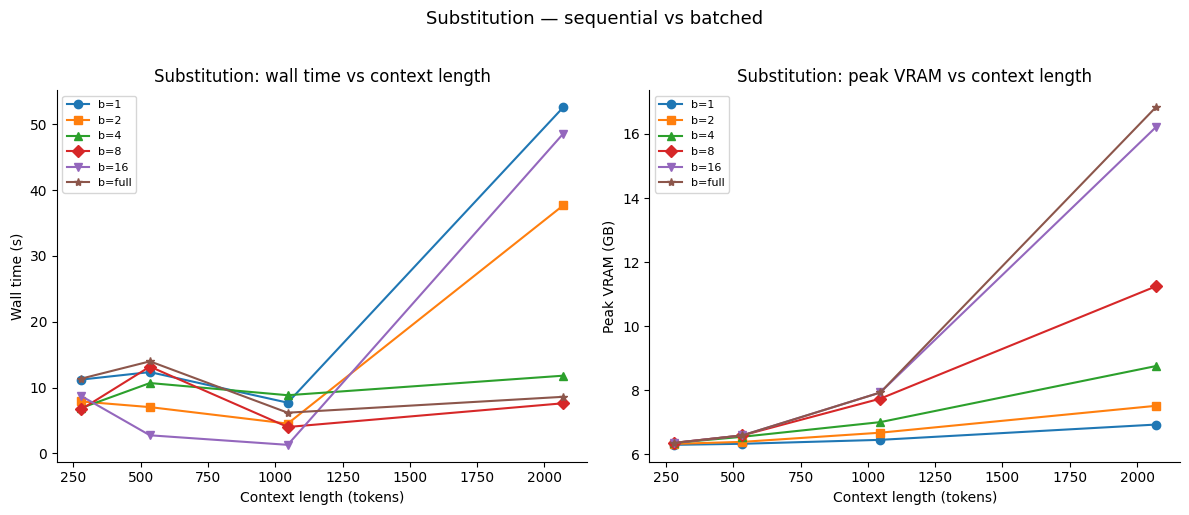

Saved → results_v2/profiling_substitution_batched.png


In [20]:
# ── Plot: Substitution — batch size comparison ────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plot_metric(ax1, profile_df, 'substitution', 'wall_time_s',  'Wall time (s)')
plot_metric(ax2, profile_df, 'substitution', 'peak_vram_gb', 'Peak VRAM (GB)')
ax1.set_title('Substitution: wall time vs context length')
ax2.set_title('Substitution: peak VRAM vs context length')
plt.suptitle('Substitution — sequential vs batched', fontsize=13, y=1.02)
plt.tight_layout()
p = os.path.join(OUTPUT_DIR, 'profiling_substitution_batched.png')
plt.savefig(p, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved → {p}')


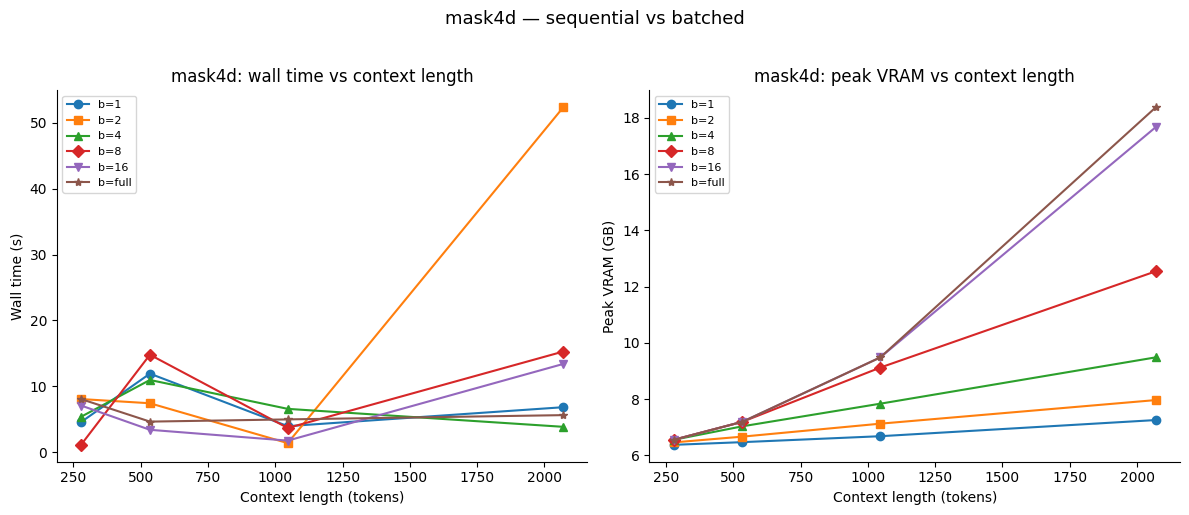

Saved → results_v2/profiling_mask4d_batched.png


In [21]:
# ── Plot: mask4d — batch size comparison ─────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plot_metric(ax1, profile_df, 'mask4d', 'wall_time_s',  'Wall time (s)')
plot_metric(ax2, profile_df, 'mask4d', 'peak_vram_gb', 'Peak VRAM (GB)')
ax1.set_title('mask4d: wall time vs context length')
ax2.set_title('mask4d: peak VRAM vs context length')
plt.suptitle('mask4d — sequential vs batched', fontsize=13, y=1.02)
plt.tight_layout()
p = os.path.join(OUTPUT_DIR, 'profiling_mask4d_batched.png')
plt.savefig(p, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved → {p}')


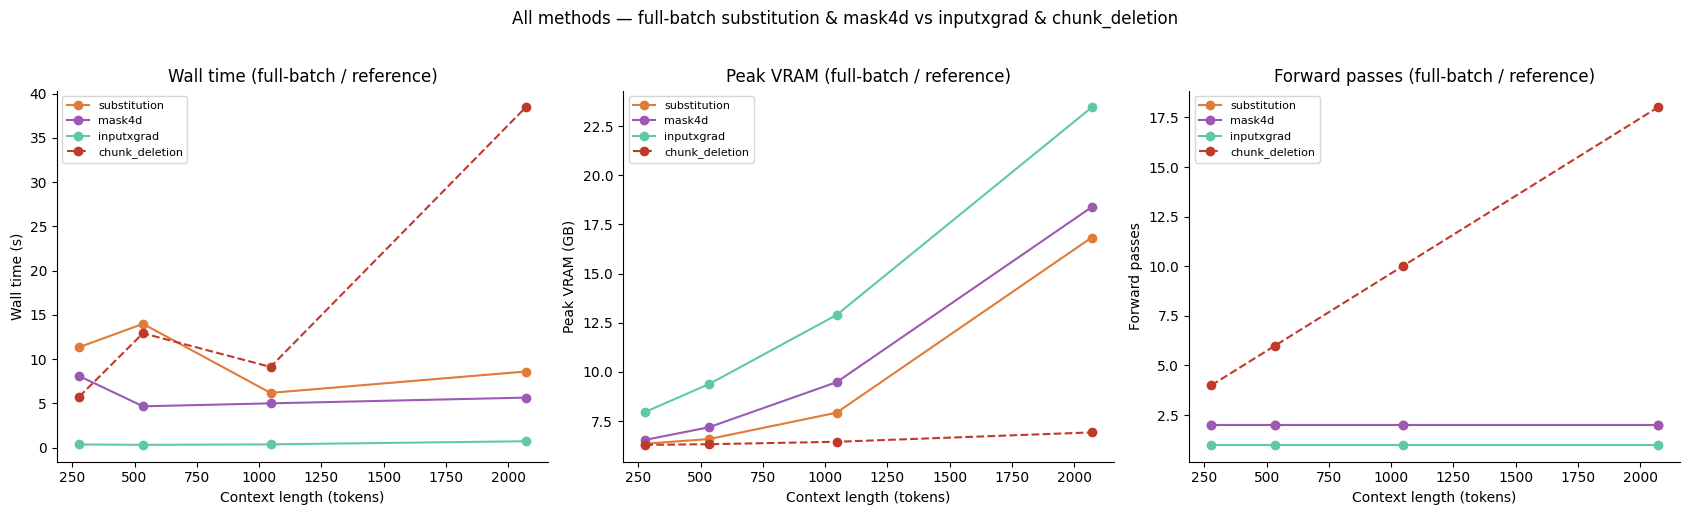

Saved → results_v2/profiling_all_fullbatch.png


In [22]:
# ── Plot: all methods — best (full) batch vs inputxgrad / chunk_deletion ──
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Full-batch rows for batchable methods
full_df = profile_df[profile_df['batch_label'] == 'full']
ref_df  = profile_df[profile_df['method'].isin(['inputxgrad', 'chunk_deletion'])]
plot_df = pd.concat([full_df, ref_df])

for method in ['substitution', 'mask4d', 'inputxgrad', 'chunk_deletion']:
    sub = plot_df[plot_df['method'] == method].sort_values('actual_tokens')
    if sub.empty: continue
    ls = '--' if method == 'chunk_deletion' else '-'
    c  = METHOD_COLORS[method]
    axes[0].plot(sub['actual_tokens'], sub['wall_time_s'],
                 marker='o', color=c, linestyle=ls, label=method)
    axes[1].plot(sub['actual_tokens'], sub['peak_vram_gb'],
                 marker='o', color=c, linestyle=ls, label=method)
    axes[2].plot(sub['actual_tokens'], sub['fwd_passes'],
                 marker='o', color=c, linestyle=ls, label=method)

for ax, ylabel, title in [
    (axes[0], 'Wall time (s)',   'Wall time (full-batch / reference)'),
    (axes[1], 'Peak VRAM (GB)',  'Peak VRAM (full-batch / reference)'),
    (axes[2], 'Forward passes',  'Forward passes (full-batch / reference)'),
]:
    ax.set_xlabel('Context length (tokens)')
    ax.set_ylabel(ylabel); ax.set_title(title); ax.legend(fontsize=8)

plt.suptitle('All methods — full-batch substitution & mask4d vs inputxgrad & chunk_deletion',
             fontsize=12, y=1.02)
plt.tight_layout()
p = os.path.join(OUTPUT_DIR, 'profiling_all_fullbatch.png')
plt.savefig(p, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved → {p}')


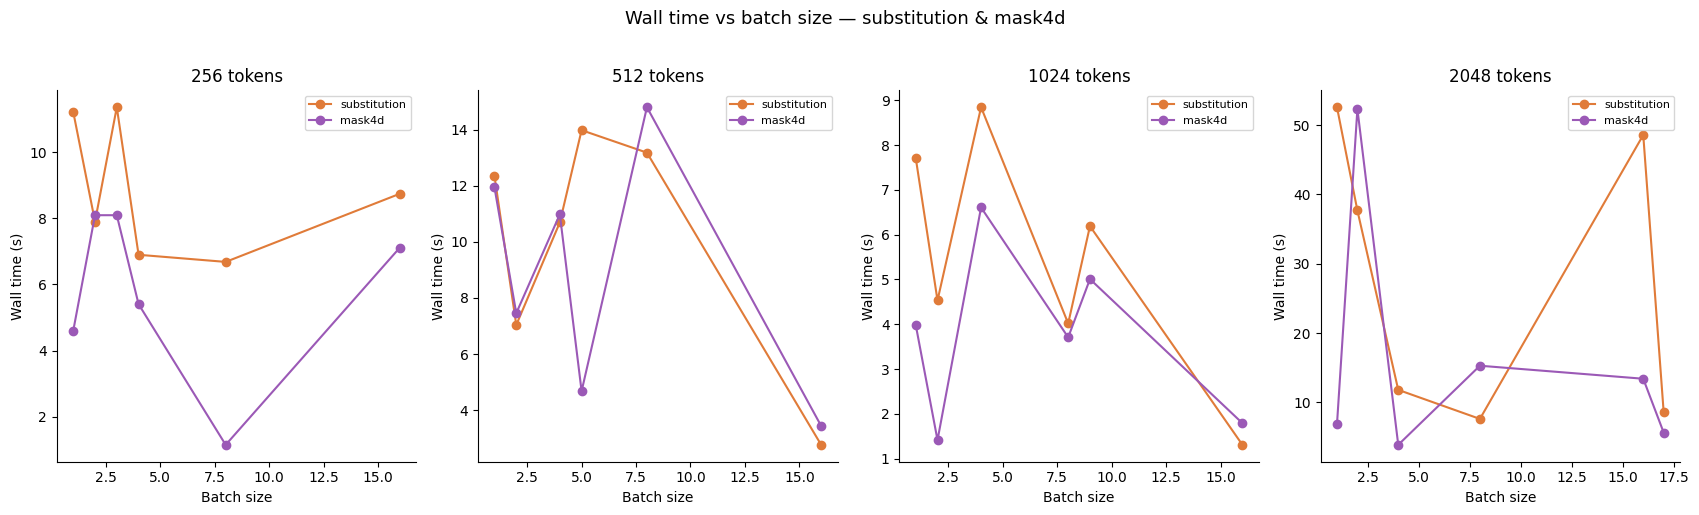

Saved → results_v2/profiling_walltime_vs_batchsize.png


In [23]:
# ── Plot: wall time vs batch size at each context length ──────────────────
# Shows the speedup curve: how much faster does each method get as batch
# size increases from 1 (sequential) to full?

batchable = profile_df[profile_df['method'].isin(['substitution', 'mask4d'])].copy()

fig, axes = plt.subplots(1, len(PROFILE_LENGTHS), figsize=(17, 5), sharey=False)

for ax, tl in zip(axes, PROFILE_LENGTHS):
    sub = batchable[batchable['target_tokens'] == tl]
    for method in ['substitution', 'mask4d']:
        m = sub[sub['method'] == method].sort_values('batch_size')
        if m.empty: continue
        ax.plot(m['batch_size'], m['wall_time_s'],
                marker='o', color=METHOD_COLORS[method], label=method)
    ax.set_xlabel('Batch size')
    ax.set_ylabel('Wall time (s)')
    ax.set_title(f'{tl} tokens')
    ax.legend(fontsize=8)

plt.suptitle('Wall time vs batch size — substitution & mask4d', fontsize=13, y=1.02)
plt.tight_layout()
p = os.path.join(OUTPUT_DIR, 'profiling_walltime_vs_batchsize.png')
plt.savefig(p, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved → {p}')


In [24]:
# ── Summary pivot tables ─────────────────────────────────────────────────
from IPython.display import display

print('Wall time (s):')
pivot = profile_df.pivot_table(index='actual_tokens',
                                columns=['method','batch_label'],
                                values='wall_time_s')
display(pivot.round(3))

print('\nPeak VRAM (GB):')
pivot = profile_df.pivot_table(index='actual_tokens',
                                columns=['method','batch_label'],
                                values='peak_vram_gb')
display(pivot.round(3))

print('\nForward passes:')
pivot = profile_df.pivot_table(index='actual_tokens',
                                columns=['method','batch_label'],
                                values='fwd_passes')
display(pivot)


Wall time (s):


method        chunk_deletion inputxgrad  mask4d                          \
batch_label              seq        n/a       1      16       2       4   
actual_tokens                                                             
278                    5.764      0.371   4.599   7.115   8.092   5.404   
534                   12.927      0.321  11.944   3.432   7.456  10.985   
1046                   9.122      0.377   3.985   1.792   1.415   6.607   
2070                  38.429      0.728   6.857  13.417  52.324   3.883   

method                       substitution                                  \
batch_label         8   full            1      16       2       4       8   
actual_tokens                                                               
278             1.153  8.092       11.215   8.741   7.899   6.896   6.681   
534            14.809  4.674       12.355   2.758   7.037  10.695  13.187   
1046            3.708  5.008        7.712   1.309   4.532   8.844   4.018   
2070           15.295  5.656       52.581  48.576  37.685  11.812   7.623   

method                 
batch_label      full  
actual_tokens          
278            11.355  
534            13.989  
1046            6.190  
2070            8.604


Peak VRAM (GB):


method        chunk_deletion inputxgrad mask4d                                \
batch_label              seq        n/a      1      16      2      4       8   
actual_tokens                                                                  
278                    6.295      7.971  6.370   6.548  6.456  6.548   6.548   
534                    6.328      9.384  6.466   7.191  6.662  7.030   7.191   
1046                   6.451     12.898  6.677   9.480  7.123  7.834   9.119   
2070                   6.928     23.448  7.252  17.677  7.963  9.483  12.545   

method                substitution                                        
batch_label      full            1      16      2      4       8    full  
actual_tokens                                                             
278             6.548        6.295   6.354  6.325  6.354   6.354   6.354  
534             7.191        6.328   6.591  6.388  6.547   6.591   6.591  
1046            9.480        6.451   7.929  6.674  7.004   7.737   7.929  
2070           18.381        6.928  16.212  7.513  8.754  11.243  16.835


Forward passes:


method        chunk_deletion inputxgrad mask4d                            \
batch_label              seq        n/a      1   16     2    4    8 full   
actual_tokens                                                              
278                      4.0        1.0    4.0  2.0   3.0  2.0  2.0  2.0   
534                      6.0        1.0    6.0  2.0   4.0  3.0  2.0  2.0   
1046                    10.0        1.0   10.0  2.0   6.0  4.0  3.0  2.0   
2070                    18.0        1.0   18.0  3.0  10.0  6.0  4.0  2.0   

method        substitution                            
batch_label              1   16     2    4    8 full  
actual_tokens                                         
278                    4.0  2.0   3.0  2.0  2.0  2.0  
534                    6.0  2.0   4.0  3.0  2.0  2.0  
1046                  10.0  2.0   6.0  4.0  3.0  2.0  
2070                  18.0  3.0  10.0  6.0  4.0  2.0

In [25]:
# ── Run all configured methods across all prompts ─────────────────────────
# Runtime estimates on H200 for 40 prompts (2 examples × 5 depths × 4 lengths):
#   substitution : ~10 min  (O(N_chunks) generate calls)
#   inputxgrad   : ~ 1 min  (O(1) forward+backward per prompt)
#   mask4d       : ~10 min  (O(N_chunks) generate calls)
#
# To do a quick smoke-test, set NUM_EXAMPLES=1 and CONTEXT_LENGTHS=[512].
# To skip slow methods during development, comment them out in METHODS above.

import time, gc

METHOD_FN = {
    'substitution': substitution_ablation,
    'inputxgrad':   inputxgrad_importance,
    'mask4d':       mask4d_ablation,
}

# inputxgrad backward pass is quadratic in seq_len — skip above this threshold
# to avoid kernel-killing OOM from VRAM fragmentation on long contexts
INPUTXGRAD_MAX_TOKENS = 2048

all_results = {m: [] for m in METHODS}
results_file = os.path.join(OUTPUT_DIR, 'all_results.json')

for prompt_idx, p in enumerate(all_prompts):
    tl = p['metadata']['target_tokens']
    d  = p['metadata']['depth_frac']
    print(f'\n[{prompt_idx+1}/{len(all_prompts)}] len={tl} depth={d:.2f}  ref={p["reference"]}')

    for method in METHODS:
        # Skip inputxgrad at long contexts — backward pass OOMs due to quadratic VRAM
        if method == 'inputxgrad' and tl > INPUTXGRAD_MAX_TOKENS:
            print(f'  [{method:14s}]  SKIPPED (len={tl} > INPUTXGRAD_MAX_TOKENS={INPUTXGRAD_MAX_TOKENS})')
            continue

        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats()
        t0 = time.time()
        try:
            res = METHOD_FN[method](p)
            elapsed = time.time() - t0
            peak_vram_gb = torch.cuda.max_memory_allocated() / 1e9
            res['prompt_idx']  = prompt_idx
            res['wall_time_s'] = round(elapsed, 3)
            res['peak_vram_gb'] = round(peak_vram_gb, 3)
            all_results[method].append(res)
            nr  = res.get('needle_rank', '?')
            ok  = res.get('baseline_correct', '?')
            print(f'  [{method:14s}]  needle_rank={nr}  baseline_correct={ok}  '
                  f'({elapsed:.1f}s  {peak_vram_gb:.2f} GB)')
        except torch.cuda.OutOfMemoryError:
            elapsed = time.time() - t0
            print(f'  [{method:14s}]  OOM after {elapsed:.1f}s — skipped')
            gc.collect()
            torch.cuda.empty_cache()
            torch.cuda.synchronize()
        except Exception as ex:
            print(f'  [{method:14s}]  ERROR: {ex}')
        finally:
            gc.collect()
            torch.cuda.empty_cache()

    # Incremental save after every prompt so a crash doesn't lose all results
    with open(results_file, 'w') as f:
        json.dump(all_results, f, indent=2)

print(f'\nResults saved → {results_file}')


[1/30] len=512 depth=0.10  ref=AJI0Y6DP
  [substitution  ]  needle_rank=3  baseline_correct=True  (6.0s  6.33 GB)
  [inputxgrad    ]  needle_rank=4  baseline_correct=True  (0.4s  9.38 GB)
  [mask4d        ]  needle_rank=3  baseline_correct=True  (1.3s  6.47 GB)

[2/30] len=512 depth=0.10  ref=DIVUZZPQ
  [substitution  ]  needle_rank=3  baseline_correct=True  (1.1s  6.33 GB)
  [inputxgrad    ]  needle_rank=3  baseline_correct=True  (0.4s  9.37 GB)
  [mask4d        ]  needle_rank=3  baseline_correct=True  (8.4s  6.47 GB)

[3/30] len=512 depth=0.25  ref=1106
  [substitution  ]  needle_rank=4  baseline_correct=True  (11.0s  6.33 GB)
  [inputxgrad    ]  needle_rank=4  baseline_correct=True  (0.5s  9.40 GB)
  [mask4d        ]  needle_rank=3  baseline_correct=True  (4.9s  6.47 GB)

[4/30] len=512 depth=0.25  ref=6574
  [substitution  ]  needle_rank=4  baseline_correct=True  (10.7s  6.33 GB)
  [inputxgrad    ]  needle_rank=4  baseline_correct=True  (0.4s  9.36 GB)
  [mask4d        ]  needle_r

## Doc-Only Ablation Evaluation

Re-runs all methods with `doc_only=True`: the question/instruction chunk is assigned
importance 0 and skipped during ablation. This gives a fairer needle retrieval score
because the question chunk no longer trivially dominates the importance ranking.

In [26]:
# ── Doc-only evaluation: ablate document region only ─────────────────────
# Identical to the main loop above, but passes doc_only=True to each method.
# The question chunk is assigned importance 0 without running a forward pass.
import time, gc, functools

METHOD_FN_DOC = {
    m: functools.partial(fn, doc_only=True)
    for m, fn in METHOD_FN.items()
}

all_results_doc  = {m: [] for m in METHODS}
results_doc_file = os.path.join(OUTPUT_DIR, 'all_results_doc.json')

for prompt_idx, p in enumerate(all_prompts):
    tl   = p['metadata']['target_tokens']
    d    = p['metadata']['depth_frac']
    qidx = p['metadata'].get('question_chunk_idx', '?')
    print(f'\n[{prompt_idx+1}/{len(all_prompts)}] len={tl} depth={d:.2f}  '
          f'q_chunk={qidx}  ref={p["reference"]}')

    for method in METHODS:
        if method == 'inputxgrad' and tl > INPUTXGRAD_MAX_TOKENS:
            print(f'  [{method:14s}]  SKIPPED (len={tl} > {INPUTXGRAD_MAX_TOKENS})')
            continue

        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats()
        t0 = time.time()
        try:
            res = METHOD_FN_DOC[method](p)
            elapsed      = time.time() - t0
            peak_vram_gb = torch.cuda.max_memory_allocated() / 1e9
            res['prompt_idx']   = prompt_idx
            res['wall_time_s']  = round(elapsed, 3)
            res['peak_vram_gb'] = round(peak_vram_gb, 3)
            all_results_doc[method].append(res)
            nr  = res.get('needle_rank', '?')
            ok  = res.get('baseline_correct', '?')
            print(f'  [{method:14s}]  needle_rank={nr}  baseline_correct={ok}  '
                  f'({elapsed:.1f}s  {peak_vram_gb:.2f} GB)')
        except torch.cuda.OutOfMemoryError:
            elapsed = time.time() - t0
            print(f'  [{method:14s}]  OOM after {elapsed:.1f}s — skipped')
            gc.collect(); torch.cuda.empty_cache(); torch.cuda.synchronize()
        except Exception as ex:
            print(f'  [{method:14s}]  ERROR: {ex}')
        finally:
            gc.collect(); torch.cuda.empty_cache()

    with open(results_doc_file, 'w') as f:
        json.dump(all_results_doc, f, indent=2)

print(f'\nDoc-only results saved → {results_doc_file}')



[1/30] len=512 depth=0.10  q_chunk=4  ref=AJI0Y6DP
  [substitution  ]  needle_rank=3  baseline_correct=True  (5.0s  6.33 GB)
  [inputxgrad    ]  needle_rank=3  baseline_correct=True  (0.6s  9.38 GB)
  [mask4d        ]  needle_rank=3  baseline_correct=True  (6.7s  6.47 GB)

[2/30] len=512 depth=0.10  q_chunk=4  ref=DIVUZZPQ
  [substitution  ]  needle_rank=3  baseline_correct=True  (2.1s  6.33 GB)
  [inputxgrad    ]  needle_rank=2  baseline_correct=True  (0.4s  9.37 GB)
  [mask4d        ]  needle_rank=3  baseline_correct=True  (9.4s  6.47 GB)

[3/30] len=512 depth=0.25  q_chunk=4  ref=1106
  [substitution  ]  needle_rank=3  baseline_correct=True  (9.8s  6.33 GB)
  [inputxgrad    ]  needle_rank=3  baseline_correct=True  (0.5s  9.40 GB)
  [mask4d        ]  needle_rank=3  baseline_correct=True  (9.3s  6.47 GB)

[4/30] len=512 depth=0.25  q_chunk=4  ref=6574
  [substitution  ]  needle_rank=3  baseline_correct=True  (3.8s  6.33 GB)
  [inputxgrad    ]  needle_rank=3  baseline_correct=True  (0

In [27]:
# ── Comparison: all-chunk ablation vs doc-only ablation ───────────────────
import pandas as pd, numpy as np
from IPython.display import display

def rank_excl_q(importances, needle_idx, q_idx):
    arr = np.array(importances, dtype=float)
    if 0 <= q_idx < len(arr): arr[q_idx] = 0.0
    return int((-arr).argsort().tolist().index(needle_idx)) + 1

def build_summary_df(results_dict, label):
    rows = []
    for method, rlist in results_dict.items():
        for r in rlist:
            m        = r.get('metadata', {})
            imps     = r.get('chunk_importances', [])
            imps_cos = r.get('chunk_importances_cosine', [])
            nidx     = r.get('needle_chunk_idx', 0)
            qidx     = m.get('question_chunk_idx', -1)
            dm       = compute_doc_metrics(imps, imps_cos, nidx, qidx) if imps and qidx >= 0 else {}
            rows.append({
                'eval':               label,
                'method':             method,
                'target_tokens':      m.get('target_tokens'),
                'depth_frac':         m.get('depth_frac'),
                'needle_rank':        r.get('needle_rank'),
                'needle_rank_cos':    r.get('needle_rank_cosine', np.nan),
                'needle_rank_no_q':   rank_excl_q(imps, nidx, qidx) if imps else np.nan,
                'needle_rank_doc':    dm.get('needle_rank_doc'),
                'needle_rank_doc_cos':dm.get('needle_rank_doc_cosine'),
                'eucr_doc':           (dm.get('eucr_doc') or {}).get('0.05', np.nan),
                'eucr_doc_cos':       (dm.get('eucr_doc_cosine') or {}).get('0.05', np.nan),
                'pwup_doc_B':         (dm.get('pwup_doc') or {}).get('B', np.nan),
                'pwup_doc_M':         (dm.get('pwup_doc') or {}).get('M', np.nan),
                'pwup_doc_E':         (dm.get('pwup_doc') or {}).get('E', np.nan),
                'gud_doc':            dm.get('gud_doc', np.nan),
            })
    return pd.DataFrame(rows)

df_all = build_summary_df(all_results,     'all_chunks')
df_doc = build_summary_df(all_results_doc, 'doc_only')
combined = pd.concat([df_all, df_doc], ignore_index=True)

summary = (
    combined.groupby(['eval', 'method', 'target_tokens'])
    .agg(
        needle_rank        = ('needle_rank',         'mean'),
        needle_rank_cos    = ('needle_rank_cos',      'mean'),
        needle_rank_no_q   = ('needle_rank_no_q',     'mean'),
        needle_rank_doc    = ('needle_rank_doc',      'mean'),
        needle_rank_doc_cos= ('needle_rank_doc_cos',  'mean'),
        eucr_doc           = ('eucr_doc',             'mean'),
        eucr_doc_cos       = ('eucr_doc_cos',         'mean'),
        pwup_doc_B         = ('pwup_doc_B',           'mean'),
        pwup_doc_M         = ('pwup_doc_M',           'mean'),
        pwup_doc_E         = ('pwup_doc_E',           'mean'),
        gud_doc            = ('gud_doc',              'mean'),
    )
    .round(3)
)

print('All-chunk vs doc-only — needle rank and document-region metrics')
print('_doc = computed over document chunks only (question chunk excluded)\n')
display(summary)

cmp_file = os.path.join(OUTPUT_DIR, 'doc_only_comparison.csv')
summary.to_csv(cmp_file)
print(f'Saved → {cmp_file}')


All-chunk vs doc-only — needle rank and document-region metrics
_doc = computed over document chunks only (question chunk excluded)



needle_rank  needle_rank_cos  \
eval       method       target_tokens                                 
all_chunks inputxgrad   512                    3.7              NaN   
                        1024                   6.1              NaN   
                        2048                  11.1              NaN   
           mask4d       512                    3.0              3.3   
                        1024                   5.9              5.5   
                        2048                   9.6              9.2   
           substitution 512                    3.4              3.3   
                        1024                   5.5              5.7   
                        2048                   8.1              8.2   
doc_only   inputxgrad   512                    2.7              NaN   
                        1024                   5.1              NaN   
                        2048                  10.1              NaN   
           mask4d       512                    2.8              2.6   
                        1024                   5.5              5.1   
                        2048                   8.3              7.7   
           substitution 512                    2.9              2.6   
                        1024                   5.0              5.1   
                        2048                   8.1              8.1   

                                       needle_rank_no_q  needle_rank_doc  \
eval       method       target_tokens                                      
all_chunks inputxgrad   512                         2.7              2.7   
                        1024                        5.1              5.1   
                        2048                       10.1             10.1   
           mask4d       512                         2.8              2.8   
                        1024                        5.5              5.5   
                        2048                        8.3              8.3   
           substitution 512                         2.9              2.9   
                        1024                        5.0              5.0   
                        2048                        8.1              8.1   
doc_only   inputxgrad   512                         2.7              2.7   
                        1024                        5.1              5.1   
                        2048                       10.1             10.1   
           mask4d       512                         2.8              2.8   
                        1024                        5.5              5.5   
                        2048                        8.3              8.3   
           substitution 512                         2.9              2.9   
                        1024                        5.0              5.0   
                        2048                        8.1              8.1   

                                       needle_rank_doc_cos  eucr_doc  \
eval       method       target_tokens                                  
all_chunks inputxgrad   512                            NaN     0.950   
                        1024                           NaN     0.575   
                        2048                           NaN     0.356   
           mask4d       512                            2.6     0.500   
                        1024                           5.1     0.600   
                        2048                           7.7     0.531   
           substitution 512                            2.6     0.475   
                        1024                           5.1     0.362   
                        2048                           8.1     0.156   
doc_only   inputxgrad   512                            NaN     0.950   
                        1024                           NaN     0.575   
                        2048                           NaN     0.356   
           mask4d       512                            2.6     0.500   
                 

Saved → results_v2/doc_only_comparison.csv


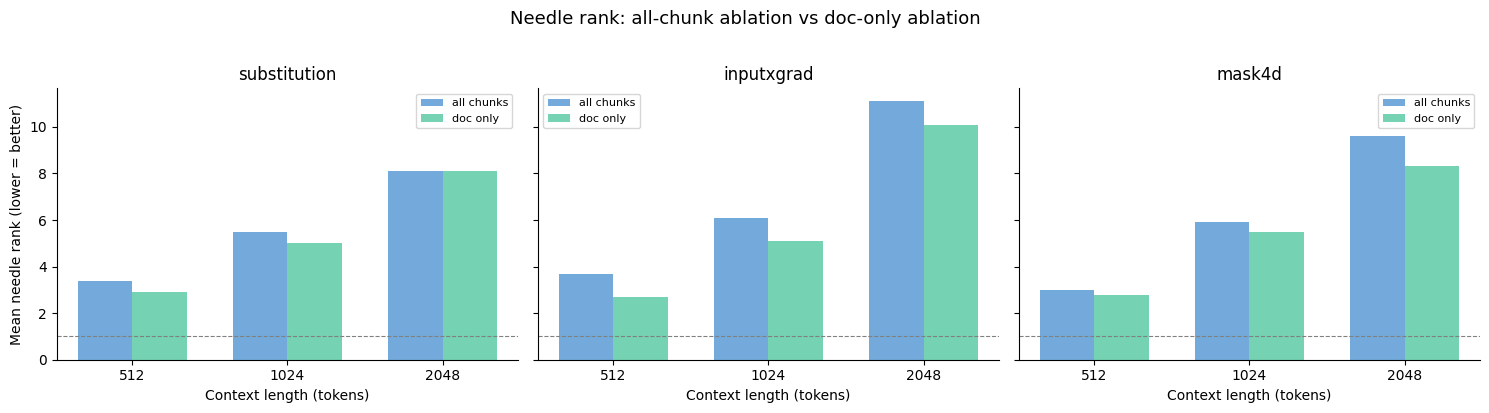

Saved → results_v2/doc_only_rank_comparison.png


In [28]:
# ── Visualisation: needle rank improvement — all-chunk vs doc-only ─────────
import matplotlib.pyplot as plt
import numpy as np

methods_plot = [m for m in METHODS]
lengths      = sorted(set(r['metadata']['target_tokens']
                           for rlist in all_results.values() for r in rlist))

fig, axes = plt.subplots(1, len(methods_plot),
                          figsize=(5 * len(methods_plot), 4), sharey=True)
if len(methods_plot) == 1: axes = [axes]

for ax, method in zip(axes, methods_plot):
    all_ranks = []
    doc_ranks = []
    for tl in lengths:
        a = [r['needle_rank'] for r in all_results.get(method, [])
             if r['metadata']['target_tokens'] == tl
             and r.get('needle_rank') is not None]
        d = [r['needle_rank'] for r in all_results_doc.get(method, [])
             if r['metadata']['target_tokens'] == tl
             and r.get('needle_rank') is not None]
        all_ranks.append(np.mean(a) if a else np.nan)
        doc_ranks.append(np.mean(d) if d else np.nan)

    x = np.arange(len(lengths))
    w = 0.35
    ax.bar(x - w/2, all_ranks, w, label='all chunks', color='#5B9BD5', alpha=0.85)
    ax.bar(x + w/2, doc_ranks, w, label='doc only',   color='#5DCAA5', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels([str(l) for l in lengths])
    ax.set_xlabel('Context length (tokens)')
    if ax is axes[0]: ax.set_ylabel('Mean needle rank (lower = better)')
    ax.set_title(method)
    ax.axhline(1, color='gray', linestyle='--', linewidth=0.8)
    ax.legend(fontsize=8)

plt.suptitle('Needle rank: all-chunk ablation vs doc-only ablation',
             fontsize=13, y=1.02)
plt.tight_layout()
p = os.path.join(OUTPUT_DIR, 'doc_only_rank_comparison.png')
plt.savefig(p, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved → {p}')


In [29]:
# ── Metrics summary table ─────────────────────────────────────────────────
import pandas as pd
import numpy as np
from IPython.display import display

EUCR_KEY = '0.05'

def rank_excl_q(importances, needle_idx, q_idx):
    arr = np.array(importances, dtype=float)
    if 0 <= q_idx < len(arr): arr[q_idx] = 0.0
    return int((-arr).argsort().tolist().index(needle_idx)) + 1

rows = []
for method, results_list in all_results.items():
    for r in results_list:
        m        = r.get('metadata', {})
        eucr     = (r.get('eucr') or {})
        pwup     = (r.get('pwup') or {})
        imps     = r.get('chunk_importances', [])
        imps_cos = r.get('chunk_importances_cosine', [])
        nidx     = r.get('needle_chunk_idx', 0)
        qidx     = m.get('question_chunk_idx', -1)

        # Doc-region metrics computed post-hoc
        dm = compute_doc_metrics(imps, imps_cos, nidx, qidx) if imps and qidx >= 0 else {}

        rows.append({
            'method':              method,
            'target_tokens':       m.get('target_tokens'),
            'depth_frac':          m.get('depth_frac'),
            'baseline_correct':    r.get('baseline_correct'),
            # ── All-chunk metrics ──
            'needle_rank':         r.get('needle_rank'),
            'needle_rank_no_q':    rank_excl_q(imps, nidx, qidx) if imps else np.nan,
            'needle_rank_doc':     dm.get('needle_rank_doc'),
            f'EUCR@{EUCR_KEY}':    eucr.get(EUCR_KEY, np.nan),
            f'EUCR_doc@{EUCR_KEY}': (dm.get('eucr_doc') or {}).get(EUCR_KEY, np.nan),
            'PWUP_B':              pwup.get('B', np.nan),
            'PWUP_M':              pwup.get('M', np.nan),
            'PWUP_E':              pwup.get('E', np.nan),
            'PWUP_doc_B':          (dm.get('pwup_doc') or {}).get('B', np.nan),
            'PWUP_doc_M':          (dm.get('pwup_doc') or {}).get('M', np.nan),
            'PWUP_doc_E':          (dm.get('pwup_doc') or {}).get('E', np.nan),
            'GUD':                 r.get('gud', np.nan),
            'GUD_doc':             dm.get('gud_doc', np.nan),
            # ── Cosine variants ──
            'needle_rank_cos':     r.get('needle_rank_cosine', np.nan),
            'needle_rank_doc_cos': dm.get('needle_rank_doc_cosine'),
            f'EUCR_cos@{EUCR_KEY}': (r.get('eucr_cosine') or {}).get(EUCR_KEY, np.nan),
            f'EUCR_doc_cos@{EUCR_KEY}': (dm.get('eucr_doc_cosine') or {}).get(EUCR_KEY, np.nan),
            'PWUP_B_cos':          (r.get('pwup_cosine') or {}).get('B', np.nan),
            'PWUP_M_cos':          (r.get('pwup_cosine') or {}).get('M', np.nan),
            'PWUP_E_cos':          (r.get('pwup_cosine') or {}).get('E', np.nan),
            'PWUP_doc_B_cos':      (dm.get('pwup_doc_cosine') or {}).get('B', np.nan),
            'PWUP_doc_M_cos':      (dm.get('pwup_doc_cosine') or {}).get('M', np.nan),
            'PWUP_doc_E_cos':      (dm.get('pwup_doc_cosine') or {}).get('E', np.nan),
            'GUD_cos':             r.get('gud_cosine', np.nan),
            'GUD_doc_cos':         dm.get('gud_doc_cosine', np.nan),
        })

df = pd.DataFrame(rows)

summary = (
    df.groupby(['method', 'target_tokens'])
      .agg(
          baseline_acc       = ('baseline_correct',        'mean'),
          # needle rank variants
          needle_rank        = ('needle_rank',              'mean'),
          needle_rank_no_q   = ('needle_rank_no_q',         'mean'),
          needle_rank_doc    = ('needle_rank_doc',          'mean'),
          needle_rank_cos    = ('needle_rank_cos',          'mean'),
          needle_rank_doc_cos= ('needle_rank_doc_cos',      'mean'),
          # all-chunk metrics
          eucr               = (f'EUCR@{EUCR_KEY}',         'mean'),
          eucr_doc           = (f'EUCR_doc@{EUCR_KEY}',     'mean'),
          pwup_b             = ('PWUP_B',                   'mean'),
          pwup_m             = ('PWUP_M',                   'mean'),
          pwup_e             = ('PWUP_E',                   'mean'),
          pwup_doc_b         = ('PWUP_doc_B',               'mean'),
          pwup_doc_m         = ('PWUP_doc_M',               'mean'),
          pwup_doc_e         = ('PWUP_doc_E',               'mean'),
          gud                = ('GUD',                      'mean'),
          gud_doc            = ('GUD_doc',                  'mean'),
          # cosine variants
          eucr_cos           = (f'EUCR_cos@{EUCR_KEY}',     'mean'),
          eucr_doc_cos       = (f'EUCR_doc_cos@{EUCR_KEY}', 'mean'),
          pwup_b_cos         = ('PWUP_B_cos',               'mean'),
          pwup_m_cos         = ('PWUP_M_cos',               'mean'),
          pwup_e_cos         = ('PWUP_E_cos',               'mean'),
          pwup_doc_b_cos     = ('PWUP_doc_B_cos',           'mean'),
          pwup_doc_m_cos     = ('PWUP_doc_M_cos',           'mean'),
          pwup_doc_e_cos     = ('PWUP_doc_E_cos',           'mean'),
          gud_cos            = ('GUD_cos',                  'mean'),
          gud_doc_cos        = ('GUD_doc_cos',              'mean'),
      )
      .round(3)
)

print(f'EUCR threshold: λ = {EUCR_KEY}')
print('_doc columns = metrics computed over document region only (excl question chunk)\n')
display(summary)

summary_file = os.path.join(OUTPUT_DIR, 'summary.csv')
summary.to_csv(summary_file)
print(f'Summary saved → {summary_file}')


EUCR threshold: λ = 0.05
_doc columns = metrics computed over document region only (excl question chunk)



baseline_acc  needle_rank  needle_rank_no_q  \
method       target_tokens                                                
inputxgrad   512                     1.0          3.7               2.7   
             1024                    1.0          6.1               5.1   
             2048                    1.0         11.1              10.1   
mask4d       512                     1.0          3.0               2.8   
             1024                    1.0          5.9               5.5   
             2048                    1.0          9.6               8.3   
substitution 512                     1.0          3.4               2.9   
             1024                    1.0          5.5               5.0   
             2048                    1.0          8.1               8.1   

                            needle_rank_doc  needle_rank_cos  \
method       target_tokens                                     
inputxgrad   512                        2.7              NaN   
             1024                       5.1              NaN   
             2048                      10.1              NaN   
mask4d       512                        2.8              3.3   
             1024                       5.5              5.5   
             2048                       8.3              9.2   
substitution 512                        2.9              3.3   
             1024                       5.0              5.7   
             2048                       8.1              8.2   

                            needle_rank_doc_cos   eucr  eucr_doc  pwup_b  \
method       target_tokens                                                 
inputxgrad   512                            NaN  0.680     0.950   0.213   
             1024                           NaN  0.311     0.575   0.242   
             2048                           NaN  0.176     0.356   0.219   
mask4d       512                            2.6  0.580     0.500   0.168   
             1024                           5.1  0.644     0.600   0.238   
             2048                           7.7  0.506     0.531   0.289   
substitution 512                            2.6  0.580     0.475   0.277   
             1024                           5.1  0.433     0.362   0.434   
             2048                           8.1  0.206     0.156   0.378   

                            pwup_m  ...  eucr_cos  eucr_doc_cos  pwup_b_cos  \
method       target_tokens          ...                                       
inputxgrad   512             0.103  ...       NaN           NaN         NaN   
             1024            0.067  ...       NaN           NaN         NaN   
             2048            0.105  ...       NaN           NaN         NaN   
mask4d       512             0.255  ...     0.580         0.500       0.177   
             1024            0.311  ...     0.500         0.462       0.210   
             2048            0.272  ...     0.300         0.294       0.172   
substitution 512             0.183  ...     0.560         0.450       0.249   
             1024            0.112  ...     0.389         0.325       0.366   
             2048            0.100  ...     0.171         0.144       0.230   

                            pwup_m_cos  pwup_e_cos  pwup_doc_b_cos  \
method       target_tokens                                           
inputxgrad   512                   NaN         NaN             NaN   
             1024                  NaN         NaN             NaN   
             2048                  NaN         NaN             NaN   
mask4d       512                 0.230       0.593           0.278   
             1024                0.250       0.540           0.181   
             2048                0.259       0.569           0.291   
substitution 512                 0.169       0.582           0.454   
             1024                0.072       0.562           0.388   
             2048                0.067       0.703           0.594   

                   

Summary saved → results_v2/summary.csv


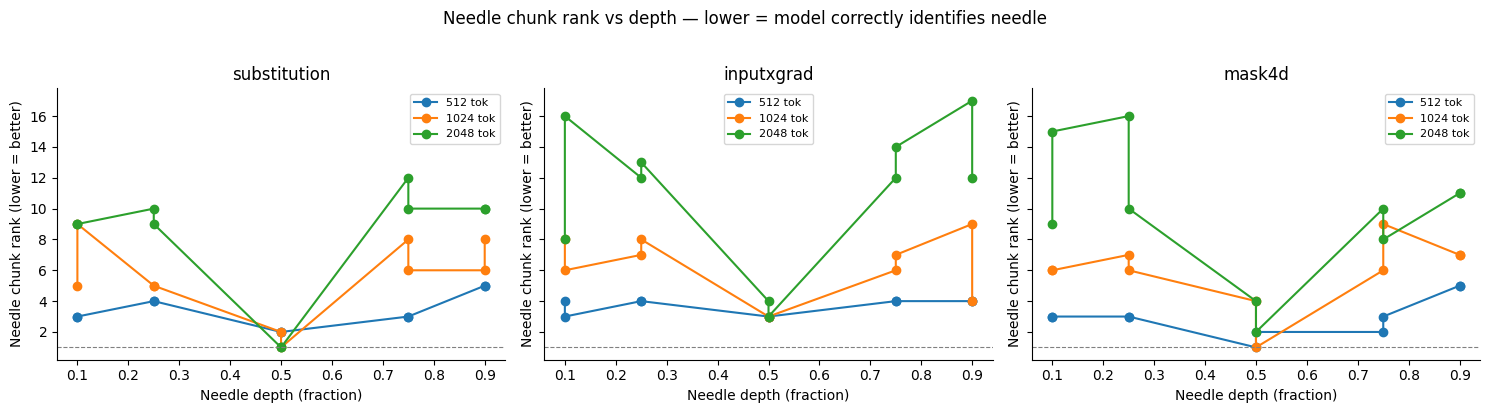

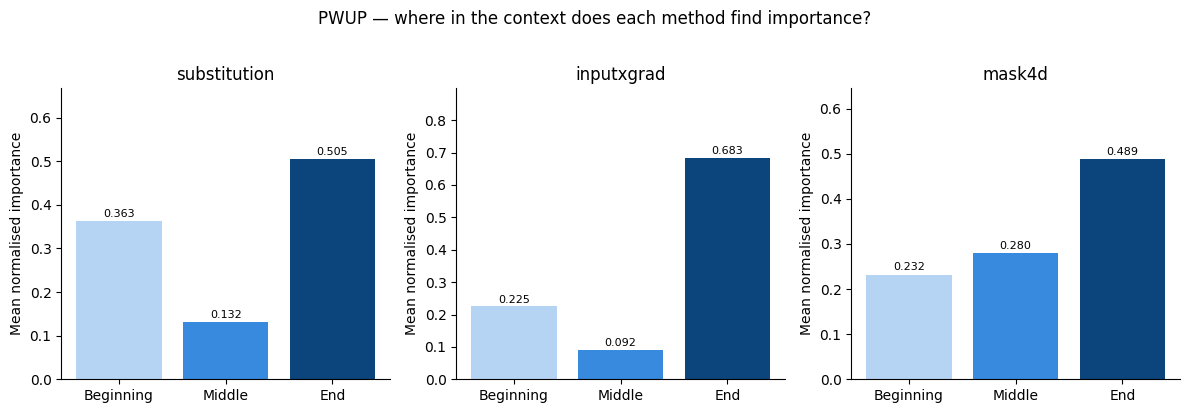

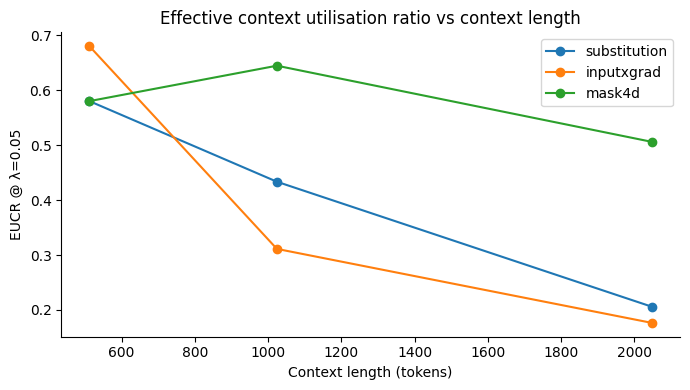

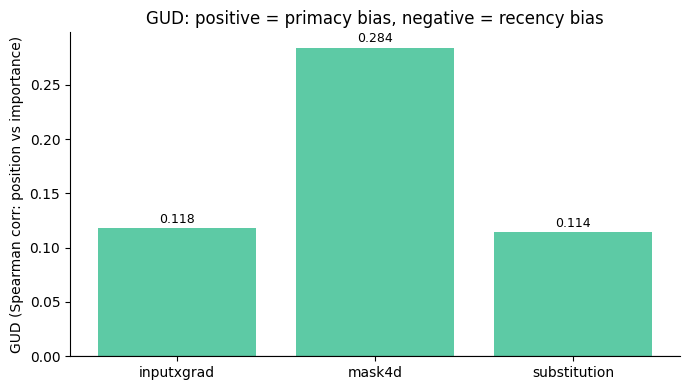

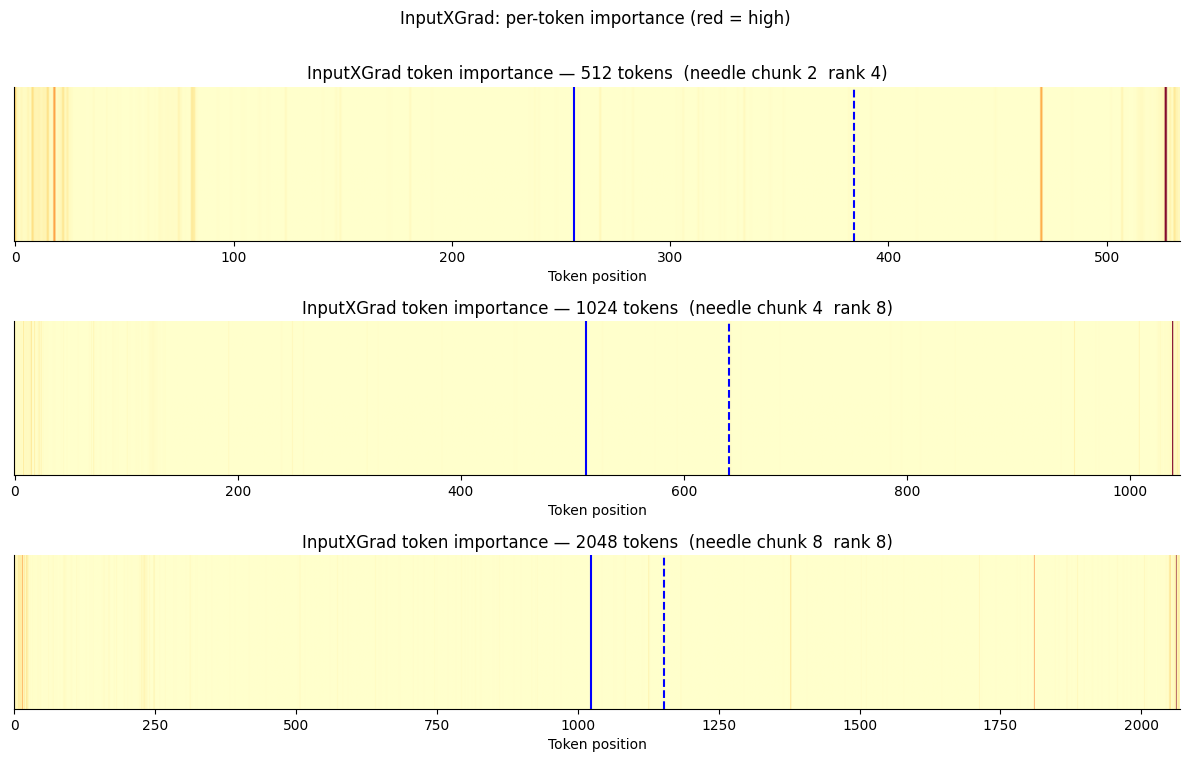

All figures saved to results_v2


In [30]:
# ── Visualizations ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

plt.rcParams.update({'font.size': 10, 'axes.spines.top': False,
                     'axes.spines.right': False})

# ── Fig 1: Needle rank by depth × method ─────────────────────────────────
fig, axes = plt.subplots(1, len(METHODS), figsize=(5 * len(METHODS), 4), sharey=True)
if len(METHODS) == 1:
    axes = [axes]
for ax, method in zip(axes, METHODS):
    sub = df[df['method'] == method]
    for tl, grp in sub.groupby('target_tokens'):
        grp_sorted = grp.sort_values('depth_frac')
        ax.plot(grp_sorted['depth_frac'], grp_sorted['needle_rank'],
                marker='o', label=f'{tl} tok')
    ax.set_title(method)
    ax.set_xlabel('Needle depth (fraction)')
    ax.set_ylabel('Needle chunk rank (lower = better)')
    ax.legend(fontsize=8)
    ax.axhline(1, color='gray', linestyle='--', linewidth=0.8)
plt.suptitle('Needle chunk rank vs depth — lower = model correctly identifies needle',
             y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'needle_rank_by_depth.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Fig 2: PWUP profiles — B/M/E bar charts per method ───────────────────
fig, axes = plt.subplots(1, len(METHODS), figsize=(4 * len(METHODS), 4))
if len(METHODS) == 1:
    axes = [axes]
regions = ['PWUP_B', 'PWUP_M', 'PWUP_E']
labels  = ['Beginning', 'Middle', 'End']
x = np.arange(3)
for ax, method in zip(axes, METHODS):
    sub = df[df['method'] == method]
    means = [sub[r].mean() for r in regions]
    bars = ax.bar(x, means, color=['#B5D4F4', '#378ADD', '#0C447C'])
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_title(method); ax.set_ylabel('Mean normalised importance')
    ax.set_ylim(0, max(means) * 1.3 + 0.01)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
plt.suptitle('PWUP — where in the context does each method find importance?', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'pwup_profiles.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Fig 3: EUCR vs context length ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
for method in METHODS:
    sub = df[df['method'] == method]
    grp = sub.groupby('target_tokens')[f'EUCR@{EUCR_KEY}'].mean()
    ax.plot(grp.index, grp.values, marker='o', label=method)
ax.set_xlabel('Context length (tokens)')
ax.set_ylabel(f'EUCR @ λ={EUCR_KEY}')
ax.set_title('Effective context utilisation ratio vs context length')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eucr_vs_length.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Fig 4: GUD (recency/primacy bias) ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
method_means = df.groupby('method')['GUD'].mean()
colors = ['#5DCAA5' if v > 0 else '#D85A30' for v in method_means.values]
ax.bar(method_means.index, method_means.values, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('GUD (Spearman corr: position vs importance)')
ax.set_title('GUD: positive = primacy bias, negative = recency bias')
for i, (name, val) in enumerate(method_means.items()):
    ax.text(i, val + (0.005 if val >= 0 else -0.02), f'{val:.3f}',
            ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'gud_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Fig 5: Per-prompt token importance heatmap (InputXGrad only) ──────────
if 'inputxgrad' in all_results and all_results['inputxgrad']:
    ixg = all_results['inputxgrad']
    # Pick one example per context length for display
    shown = {}
    for r in ixg:
        tl = r['metadata']['target_tokens']
        if tl not in shown:
            shown[tl] = r
    n = len(shown)
    fig, axes = plt.subplots(n, 1, figsize=(12, 2.5 * n))
    if n == 1: axes = [axes]
    for ax, (tl, r) in zip(axes, sorted(shown.items())):
        imps = np.array(r['token_importances'])
        imps_norm = (imps - imps.min()) / (imps.max() - imps.min() + 1e-9)
        ax.imshow(imps_norm.reshape(1, -1), aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
        ax.set_yticks([])
        ax.set_xlabel('Token position')
        ax.set_title(f'InputXGrad token importance — {tl} tokens  '
                     f'(needle chunk {r["needle_chunk_idx"]}  rank {r["needle_rank"]})')
        # Mark needle chunk
        nc  = r['needle_chunk_idx']
        s   = nc * CHUNK_SIZE
        e   = min(s + CHUNK_SIZE, len(imps))
        ax.axvline(s, color='blue', linewidth=1.5, label='needle start')
        ax.axvline(e, color='blue', linewidth=1.5, linestyle='--')
    plt.suptitle('InputXGrad: per-token importance (red = high)', y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'inputxgrad_heatmap.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

print('All figures saved to', OUTPUT_DIR)

## Individual Per-Prompt Results

Per-call latency, VRAM, discrete and cosine needle rank for every prompt × method combination.

In [31]:
# ── Build flat per-prompt DataFrame ──────────────────────────────────────
import pandas as pd, numpy as np
from IPython.display import display

indiv_rows = []
for method, results_list in all_results.items():
    for r in results_list:
        m = r.get('metadata', {})
        indiv_rows.append({
            'method':          method,
            'prompt_idx':      r.get('prompt_idx'),
            'target_tokens':   m.get('target_tokens'),
            'depth_frac':      m.get('depth_frac'),
            'baseline_correct':r.get('baseline_correct'),
            'needle_rank':     r.get('needle_rank'),
            'needle_rank_cos': r.get('needle_rank_cosine'),
            'wall_time_s':     r.get('wall_time_s'),
            'peak_vram_gb':    r.get('peak_vram_gb'),
            'eucr':            (r.get('eucr')        or {}).get('0.05', np.nan),
            'eucr_cos':        (r.get('eucr_cosine') or {}).get('0.05', np.nan),
        })

indiv_df = pd.DataFrame(indiv_rows)
indiv_csv = os.path.join(OUTPUT_DIR, 'individual_results.csv')
indiv_df.to_csv(indiv_csv, index=False)
print(f'Individual results: {len(indiv_df)} rows  →  {indiv_csv}')
display(indiv_df.sort_values(['method','target_tokens','depth_frac']).reset_index(drop=True))


Individual results: 90 rows  →  results_v2/individual_results.csv


,method,prompt_idx,target_tokens,depth_frac,baseline_correct,needle_rank,needle_rank_cos,wall_time_s,peak_vram_gb,eucr,eucr_cos
0,inputxgrad,0,512,0.10,True,4,NaN,0.352,9.384,0.400000,NaN
1,inputxgrad,1,512,0.10,True,3,NaN,0.355,9.371,0.400000,NaN
2,inputxgrad,2,512,0.25,True,4,NaN,0.465,9.401,0.600000,NaN
3,inputxgrad,3,512,0.25,True,4,NaN,0.377,9.365,0.600000,NaN
4,inputxgrad,4,512,0.50,True,3,NaN,0.426,9.371,0.800000,NaN
...,...,...,...,...,...,...,...,...,...,...,...
85,substitution,25,2048,0.50,True,1,1.0,13.344,6.927,0.235294,0.176471
86,substitution,26,2048,0.75,True,12,12.0,30.459,6.928,0.294118,0.235294
87,substitution,27,2048,0.75,True,10,10.0,30.747,6.928,0.176471,0.176471
88,substitution,28,2048,0.90,True,10,10.0,35.213,6.928,0.176471,0.176471


/tmp/ipykernel_703039/1781477256.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


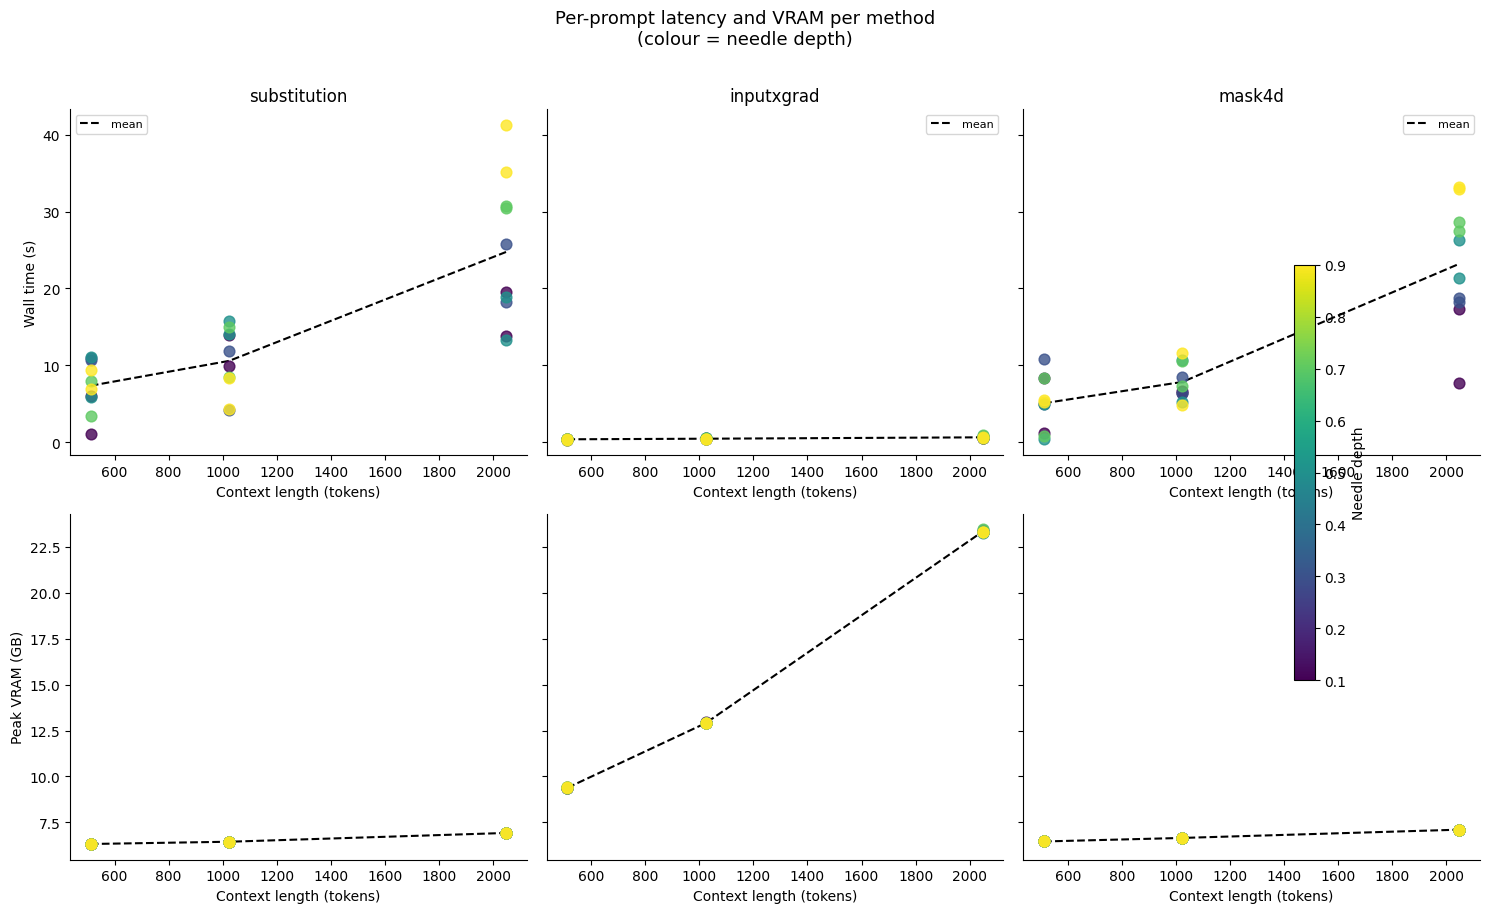

Saved → results_v2/indiv_latency_vram.png


In [32]:
# ── Per-prompt: latency and VRAM per method ───────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.cm as cm

methods = indiv_df['method'].unique()
n = len(methods)
fig, axes = plt.subplots(2, n, figsize=(5*n, 9), sharey='row')
if n == 1:
    axes = axes.reshape(2, 1)

cmap   = plt.get_cmap('viridis')
depths = sorted(indiv_df['depth_frac'].unique())
d_norm = {d: i/(len(depths)-1) if len(depths)>1 else 0.5 for i, d in enumerate(depths)}

for col, method in enumerate(methods):
    sub = indiv_df[indiv_df['method'] == method]

    # ── Row 0: wall time ──
    ax = axes[0, col]
    for _, row in sub.iterrows():
        color = cmap(d_norm[row['depth_frac']])
        ax.scatter(row['target_tokens'], row['wall_time_s'],
                   color=color, s=60, alpha=0.8, zorder=3)
    # mean line
    means = sub.groupby('target_tokens')['wall_time_s'].mean()
    ax.plot(means.index, means.values, color='black', linewidth=1.5,
            linestyle='--', label='mean')
    ax.set_title(method)
    ax.set_xlabel('Context length (tokens)')
    if col == 0: ax.set_ylabel('Wall time (s)')
    ax.legend(fontsize=8)

    # ── Row 1: VRAM ──
    ax = axes[1, col]
    for _, row in sub.iterrows():
        color = cmap(d_norm[row['depth_frac']])
        ax.scatter(row['target_tokens'], row['peak_vram_gb'],
                   color=color, s=60, alpha=0.8, zorder=3)
    means = sub.groupby('target_tokens')['peak_vram_gb'].mean()
    ax.plot(means.index, means.values, color='black', linewidth=1.5, linestyle='--')
    ax.set_xlabel('Context length (tokens)')
    if col == 0: ax.set_ylabel('Peak VRAM (GB)')

# Colorbar for depth
sm = plt.cm.ScalarMappable(cmap=cmap,
     norm=plt.Normalize(vmin=min(depths), vmax=max(depths)))
sm.set_array([])
fig.colorbar(sm, ax=axes[:, -1], label='Needle depth', shrink=0.6)

plt.suptitle('Per-prompt latency and VRAM per method\n(colour = needle depth)',
             fontsize=13, y=1.01)
plt.tight_layout()
p = os.path.join(OUTPUT_DIR, 'indiv_latency_vram.png')
plt.savefig(p, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved → {p}')


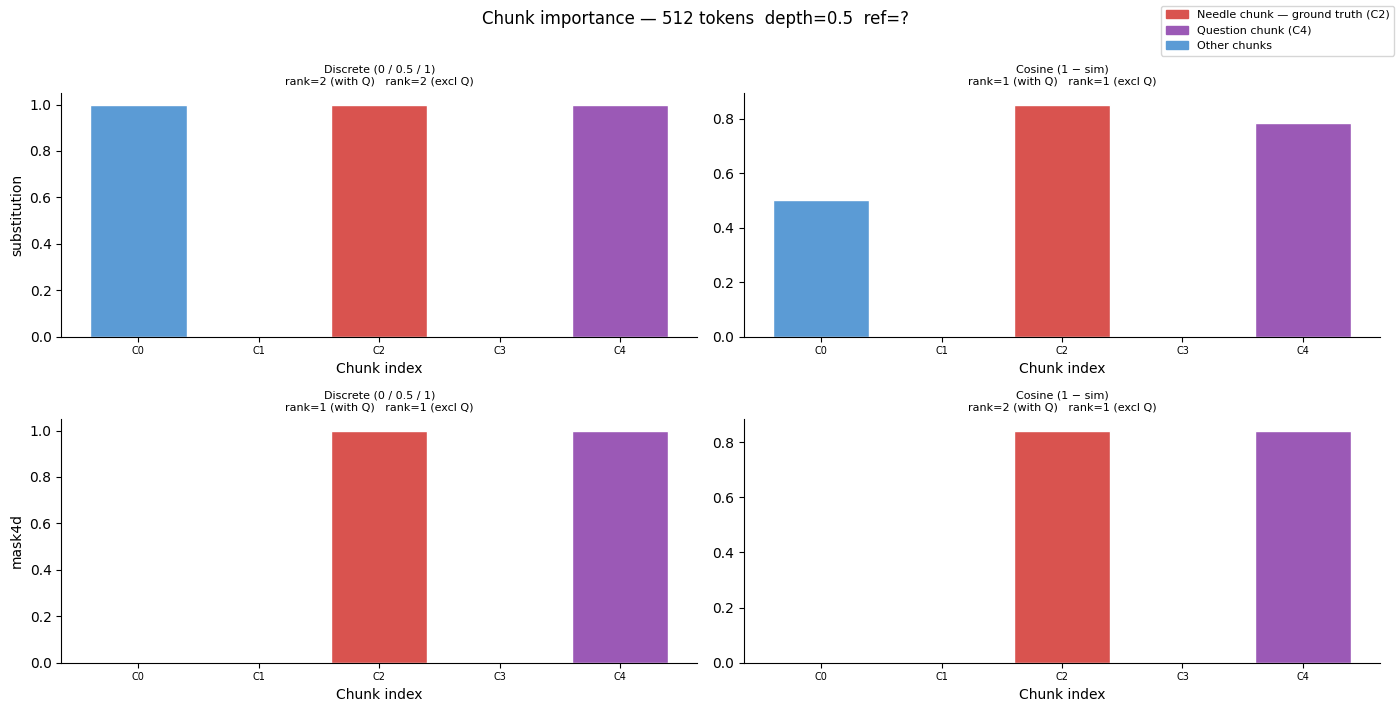

Saved → results_v2/influence_profiles_512.png


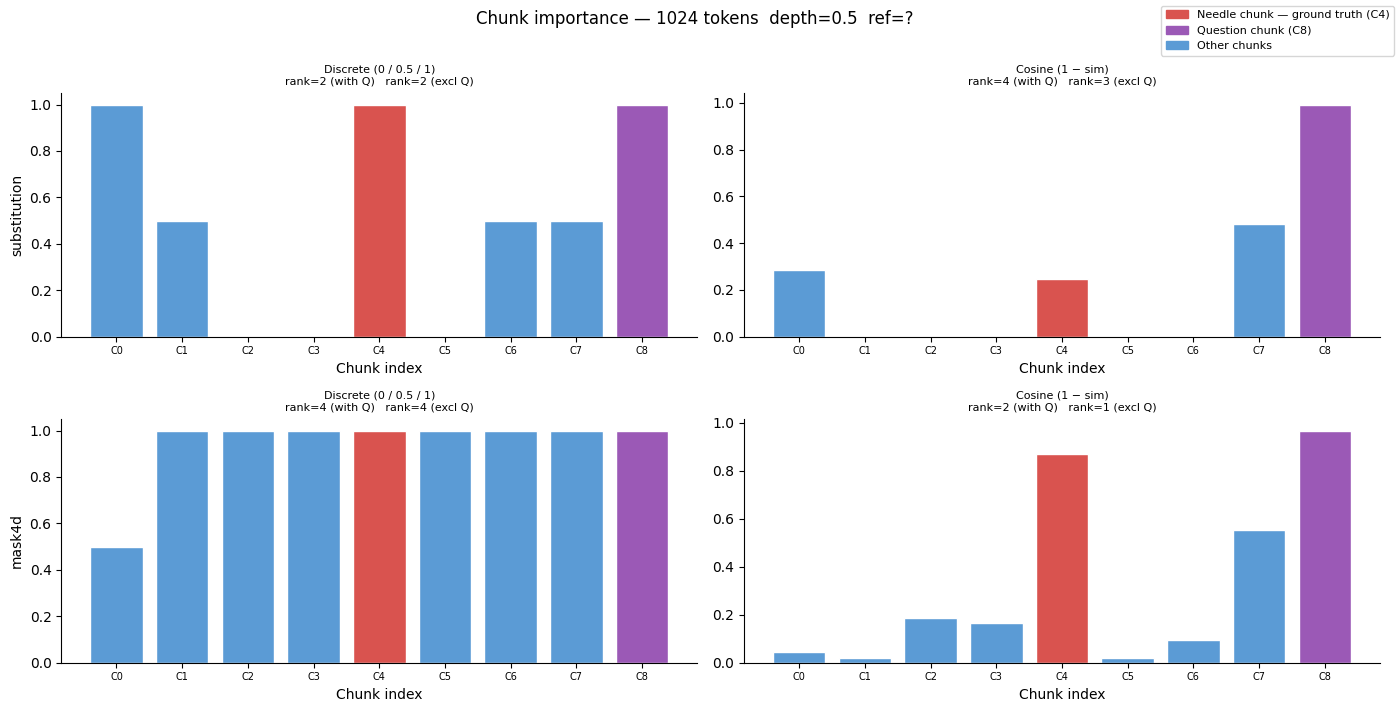

Saved → results_v2/influence_profiles_1024.png


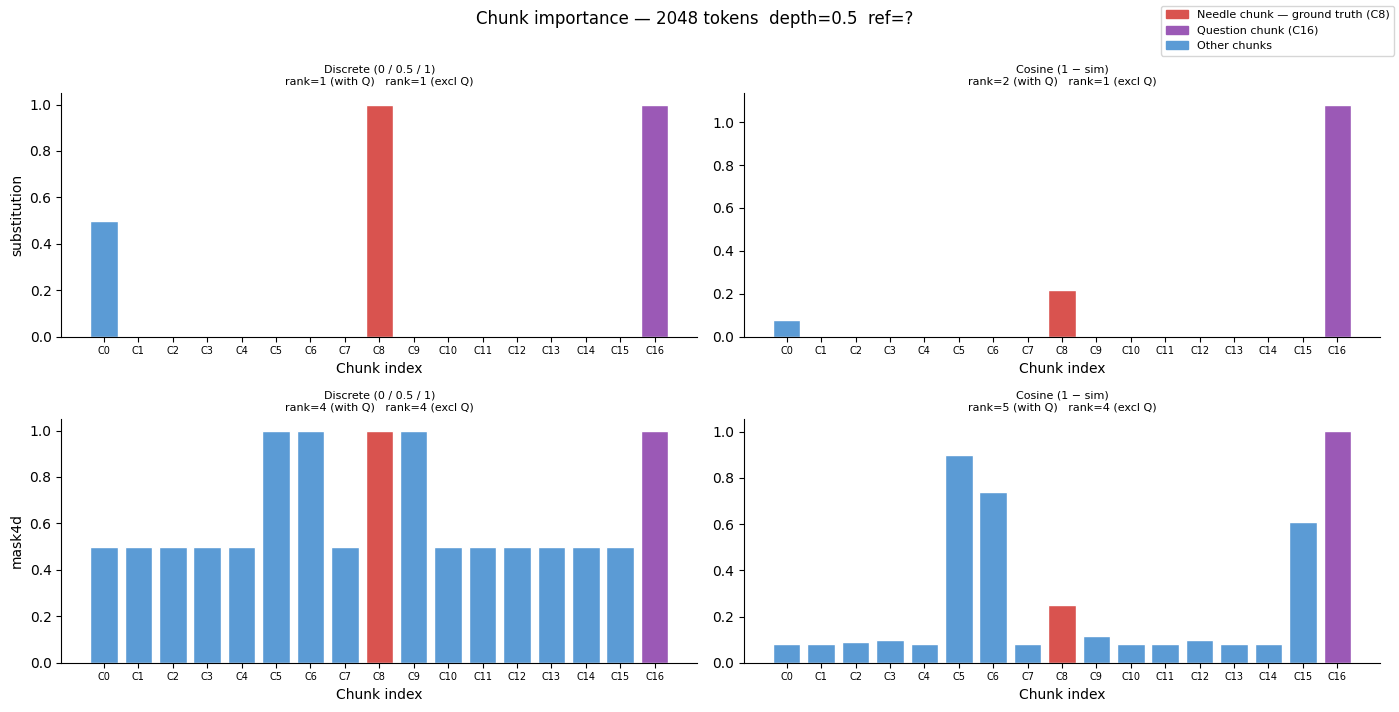

Saved → results_v2/influence_profiles_2048.png


In [33]:
# ── Per-prompt chunk influence profiles (needle + question highlighted) ───
# For each context length, pick the depth=0.5 prompt and show discrete
# and cosine chunk importances side by side for all generation methods.
# Red    = needle chunk (ground truth answer)
# Purple = question chunk (question text — typically dominates)
# Title shows needle rank WITH and WITHOUT question chunk for both scorings.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

TARGET_DEPTH = 0.5
SHOW_LENGTHS = sorted(indiv_df['target_tokens'].unique())
methods_gen  = [m for m in METHODS if m != 'inputxgrad']

def rank_excl_q(importances, needle_idx, q_idx):
    arr = np.array(importances, dtype=float)
    if 0 <= q_idx < len(arr):
        arr[q_idx] = 0.0
    return int((-arr).argsort().tolist().index(needle_idx)) + 1

for tl in SHOW_LENGTHS:
    candidates = [
        r for m, rlist in all_results.items()
        for r in rlist
        if r['metadata']['target_tokens'] == tl
        and abs(r['metadata']['depth_frac'] - TARGET_DEPTH) < 0.01
        and m == methods_gen[0]
    ]
    if not candidates:
        continue
    ref        = candidates[0]['metadata'].get('reference', '?')
    needle_idx = candidates[0]['needle_chunk_idx']
    q_idx      = candidates[0]['metadata'].get('question_chunk_idx', -1)

    fig, axes = plt.subplots(len(methods_gen), 2,
                              figsize=(14, 3.5 * len(methods_gen)), sharey=False)
    if len(methods_gen) == 1:
        axes = axes.reshape(1, 2)

    for row, method in enumerate(methods_gen):
        match = next(
            (r for r in all_results.get(method, [])
             if r['metadata']['target_tokens'] == tl
             and abs(r['metadata']['depth_frac'] - TARGET_DEPTH) < 0.01),
            None)
        if match is None:
            continue

        nidx  = match['needle_chunk_idx']
        qidx  = match['metadata'].get('question_chunk_idx', -1)

        for col, (imp_key, title_sfx) in enumerate([
            ('chunk_importances',        'Discrete (0 / 0.5 / 1)'),
            ('chunk_importances_cosine', 'Cosine (1 − sim)'),
        ]):
            ax   = axes[row, col]
            imps = match.get(imp_key, [])
            if not imps:
                continue

            colors = []
            for i in range(len(imps)):
                if i == nidx:
                    colors.append('#D9534F')
                elif i == qidx:
                    colors.append('#9B59B6')
                else:
                    colors.append('#5B9BD5')
            ax.bar(range(len(imps)), imps, color=colors, edgecolor='white')
            ax.set_xticks(range(len(imps)))
            ax.set_xticklabels([f'C{i}' for i in range(len(imps))], fontsize=7)
            ax.set_xlabel('Chunk index')
            if col == 0:
                ax.set_ylabel(method)

            nr      = match.get('needle_rank_cosine' if col else 'needle_rank', '?')
            nr_no_q = rank_excl_q(imps, nidx, qidx) if imps else '?'
            ax.set_title(
                f'{title_sfx}\n'
                f'rank={nr} (with Q)   rank={nr_no_q} (excl Q)',
                fontsize=8,
            )
            ax.axhline(0, color='black', linewidth=0.5)

    needle_p = mpatches.Patch(color='#D9534F', label=f'Needle chunk — ground truth (C{needle_idx})')
    quest_p  = mpatches.Patch(color='#9B59B6', label=f'Question chunk (C{q_idx})')
    other_p  = mpatches.Patch(color='#5B9BD5', label='Other chunks')
    fig.legend(handles=[needle_p, quest_p, other_p], loc='upper right', fontsize=8)
    plt.suptitle(
        f'Chunk importance — {tl} tokens  depth={TARGET_DEPTH}  ref={ref}',
        fontsize=12, y=1.01,
    )
    plt.tight_layout()
    p = os.path.join(OUTPUT_DIR, f'influence_profiles_{tl}.png')
    plt.savefig(p, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {p}')


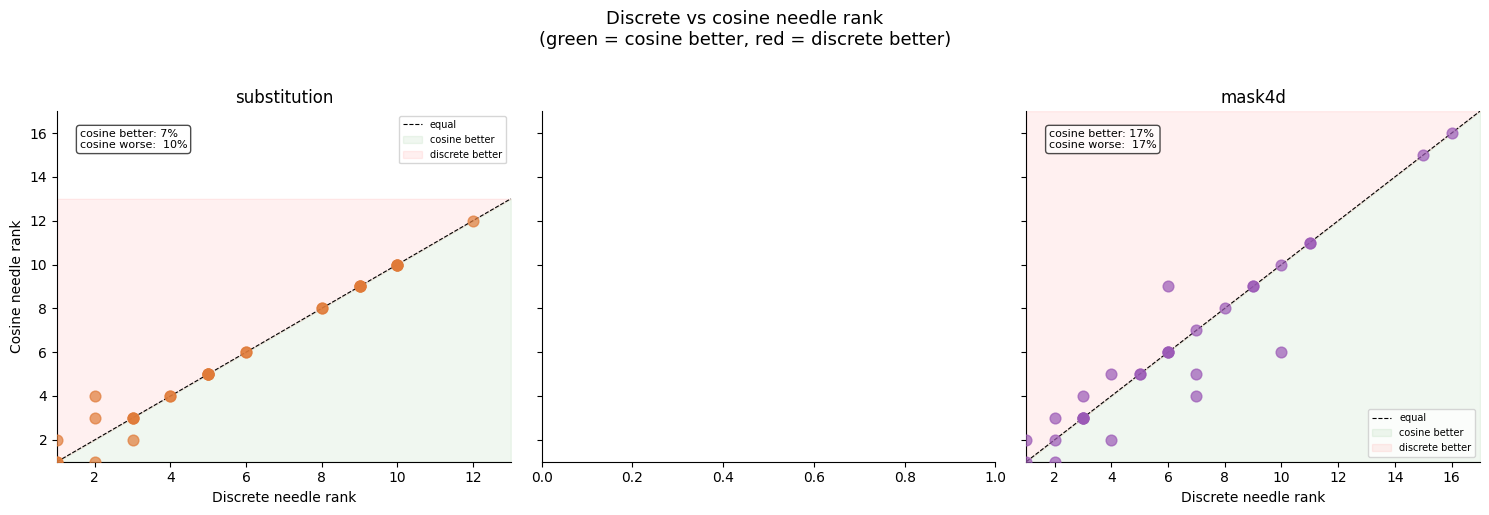

Saved → results_v2/rank_discrete_vs_cosine.png


In [34]:
# ── Discrete vs cosine needle rank: scatter comparison ────────────────────
import matplotlib.pyplot as plt
import numpy as np

method_colors = {
    'substitution':  '#E07B39',
    'mask4d':        '#9B59B6',
    'inputxgrad':    '#5DCAA5',
    'chunk_deletion':'#C0392B',
}

fig, axes = plt.subplots(1, len(METHODS), figsize=(5*len(METHODS), 5), sharey=True)
if len(METHODS) == 1: axes = [axes]

for ax, method in zip(axes, METHODS):
    sub = indiv_df[indiv_df['method'] == method].dropna(subset=['needle_rank','needle_rank_cos'])
    if sub.empty: continue

    ax.scatter(sub['needle_rank'], sub['needle_rank_cos'],
               color=method_colors.get(method,'gray'),
               alpha=0.7, s=60, zorder=3)

    # Diagonal: both metrics agree
    lim = max(sub['needle_rank'].max(), sub['needle_rank_cos'].max()) + 1
    ax.plot([1, lim], [1, lim], 'k--', linewidth=0.8, label='equal')

    # Shade where cosine is better (below diagonal)
    ax.fill_between([1, lim], [1, 1], [1, lim],
                    alpha=0.06, color='green', label='cosine better')
    ax.fill_between([1, lim], [1, lim], [lim, lim],
                    alpha=0.06, color='red', label='discrete better')

    ax.set_xlim(1, lim); ax.set_ylim(1, lim)
    ax.set_xlabel('Discrete needle rank')
    if ax is axes[0]: ax.set_ylabel('Cosine needle rank')
    ax.set_title(method)
    ax.legend(fontsize=7)

    # Improvement stats
    better = (sub['needle_rank_cos'] < sub['needle_rank']).mean()
    worse  = (sub['needle_rank_cos'] > sub['needle_rank']).mean()
    ax.text(0.05, 0.95, f'cosine better: {better:.0%}\ncosine worse:  {worse:.0%}',
            transform=ax.transAxes, fontsize=8, va='top',
            bbox=dict(boxstyle='round', fc='white', alpha=0.7))

plt.suptitle('Discrete vs cosine needle rank\n'
             '(green = cosine better, red = discrete better)',
             fontsize=13, y=1.02)
plt.tight_layout()
p = os.path.join(OUTPUT_DIR, 'rank_discrete_vs_cosine.png')
plt.savefig(p, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved → {p}')


## Interpreting the results

### What each method tells you
- **Substitution (A)** — behavioural oracle: if the answer breaks when chunk i is replaced,  
  chunk i was causally necessary. High precision, high cost.
- **InputXGrad (B)** — gradient signal: how much does the loss change if we perturb  
  the embedding of token i? Cheap, continuous, works even when the model answers  
  correctly everywhere (captures *degree* of importance, not just binary break).
- **Attention aggregation (C)** — attention as proxy: which context positions do the  
  question tokens "look at"? Note: attention ≠ importance (see Jain & Wallace 2019),  
  but correlates well with needle position for retrieval-focused prompts.
- **4-D mask (D)** — clean causal ablation: blocks the information flow FROM chunk i  
  at every layer without touching positions. Closest to the ideal counterfactual  
  "what if this text were invisible?"

### Key differences from the original implementation
| Issue | Old code | v2 |
|-------|----------|----|
| RoPE validity | ❌ token deletion shifts positions | ✅ positions never change |
| Mask semantics | ❌ 1-D padding mask | ✅ 4-D causal block mask |
| Cost | O(N_chunks) generate calls | B/C: O(1); A/D: O(N_chunks) |
| Needle position coverage | only `middle` | 5 depths (0.1→0.9) |
| Examples per config | 1 | configurable (default 2) |

### Suggested writeup framing
Compare needle_rank across methods and depths. A well-utilising model should  
show needle_rank = 1 regardless of depth. The "lost in the middle" effect  
(Liu et al. 2023) predicts rank degrades for depths near 0.5 relative to  
0.1 and 0.9 (primacy + recency bias). Your GUD metric quantifies this.